# AD Classifier 

## Imports and Configurations

In [57]:
import subprocess, sys, os, gc, random, warnings, copy, re, pathlib, pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
    roc_auc_score, accuracy_score, balanced_accuracy_score)

import torchvision.models as tvm
import torchvision.transforms.functional as TF

warnings.filterwarnings('ignore')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch: {torch.__version__}  |  Device: {DEVICE}")

#  Paths 
DATA_ROOT  = "/workspace/Data/NACC_Combined_AUG"
CSV_PATH   = "/workspace/Data/500_patients.csv"
MODEL_SAVE = "/workspace/Outputs/ad_classifier_v4/cross_attn_v4_best.pt"
OUT_DIR    = "/workspace/Outputs/ad_classifier_v4/xai_outputs_v4"

#  Training hyperparameters ─
BATCH_SIZE   = 8
EPOCHS       = 70
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2
SEED         = 42
K_FOLDS      = 3
EMBED_DIM    = 256
NUM_HEADS    = 8
DROPOUT      = 0.4
MC_SAMPLES   = 30
N_SLICES     = 5
VIEW_DROPOUT_P = 0.20

#  Multi-task loss weights 
ALPHA_CLS  = 1.0   # weight for final classification loss
BETA_CLS   = 0.8   # weight for clinical-only auxiliary classification loss
GAMMA_REG  = 0.4   # weight for MoCA regression loss

#  Modality simulation & trust weights ─
# PET_MISSING_DROPOUT_P: fraction of training steps where real PET is
# artificially zeroed to simulate the clinical "no real PET" scenario.
# The model also receives real_pet_mask=False so trust weighting fires.
# Increase to make the model more robust to missing PET at inference.
PET_MISSING_DROPOUT_P = 0.45   # ← change this to adjust simulation rate

# When a patient has NO real PET (only synthetic PET available):
#   fused-MRI token weight = MRI_WEIGHT_NO_PET  (e.g. 0.70 → 70% MRI influence)
#   synPET token weight    = SYN_WEIGHT_NO_PET  (e.g. 0.30 → 30% synPET influence)
#   real PET token         = 0 (always zeroed when absent)
# When a patient HAS real PET: all three tokens get equal weight (1/3 each).
MRI_WEIGHT_NO_PET = 0.65   # ← change to adjust MRI trust when synPET only
SYN_WEIGHT_NO_PET = 0.35   # ← change to adjust synPET trust when synPET only
assert abs(MRI_WEIGHT_NO_PET + SYN_WEIGHT_NO_PET - 1.0) < 1e-6, \
    "MRI_WEIGHT_NO_PET + SYN_WEIGHT_NO_PET must equal 1.0"

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_SAVE), exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)

LABEL_MAP    = {1:0, 3:1, 4:2}
CLASS_NAMES  = ["CN (Normal)", "MCI", "AD"]
CLASS_COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]
VIEW_NAMES   = ["Axial", "Coronal", "Sagittal"]
print("Config loaded")
print(f"  PET missing dropout : {PET_MISSING_DROPOUT_P*100:.0f}% of training steps")
print(f"  Trust (no real PET) : MRI {MRI_WEIGHT_NO_PET*100:.0f}% / synPET {SYN_WEIGHT_NO_PET*100:.0f}%")
print(f"  Trust (has real PET): MRI 33% / rPET 33% / sPET 33% (equal)")


PyTorch: 2.11.0+cu128  |  Device: cuda
Config loaded
  PET missing dropout : 45% of training steps
  Trust (no real PET) : MRI 65% / synPET 35%
  Trust (has real PET): MRI 33% / rPET 33% / sPET 33% (equal)


## Clinical features from CSV

In [58]:
df_raw = pd.read_csv(CSV_PATH)
df = df_raw[df_raw['NACCUDSD'].isin(LABEL_MAP.keys())].copy()
df['label'] = df['NACCUDSD'].map(LABEL_MAP)
df['cog_score_norm'] = df['MOCATOTS'].apply(lambda x: float(x)/30.0 if x >= 0 else np.nan)

BASE_COLS = ['NACCAGE', 'SEX', 'EDUC', 'NACCAPOE', 'CDRSUM']
for c in BASE_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(df[c].median() if c != 'CDRSUM' else 0.0)

df['CDR_zero']    = (df['CDRSUM'] == 0.0).astype(float)
df['CDR_mid']     = ((df['CDRSUM'] > 0) & (df['CDRSUM'] < 1)).astype(float)
df['CDR_severe']  = (df['CDRSUM'] >= 1.0).astype(float)
df['CDR_0_0_5']   = ((df['CDRSUM'] > 0) & (df['CDRSUM'] <= 0.5)).astype(float)
df['CDR_0_5_1']   = ((df['CDRSUM'] > 0.5) & (df['CDRSUM'] < 1)).astype(float)
df['CDR_clip']    = df['CDRSUM'].clip(0, 1).astype(float)
df['APOE4']       = df['NACCAPOE'].apply(lambda x: 1.0 if x in [4, 5] else 0.0)
df['AGE_60_70']   = ((df['NACCAGE'] >= 60) & (df['NACCAGE'] < 70)).astype(float)
df['AGE_70_80']   = ((df['NACCAGE'] >= 70) & (df['NACCAGE'] < 80)).astype(float)
df['AGE_80_plus'] = (df['NACCAGE'] >= 80).astype(float)
df['AGE_old']     = (df['NACCAGE'] > 75).astype(float)

ALL_CLIN_COLS = BASE_COLS + [
    'CDR_zero','CDR_mid','CDR_severe','CDR_0_0_5','CDR_0_5_1','CDR_clip',
    'APOE4','AGE_60_70','AGE_70_80','AGE_80_plus','AGE_old'
]
for c in ALL_CLIN_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0.0)

clin_scaler = StandardScaler()
print("Clinical feature vector size:", len(ALL_CLIN_COLS))


Clinical feature vector size: 16


## Discover subjects within the dataset

In [59]:
def discover_subjects(data_root, df_clinical):
    records = []
    if not os.path.isdir(data_root):
        print(f"!! DATA_ROOT not found: {data_root}"); return records
    clin_lookup = {str(nid): row for nid, row in df_clinical.set_index('NACCID').iterrows()}
    skipped_no_csv = skipped_no_mri = skipped_no_imaging = 0
    for folder in sorted(os.listdir(data_root)):
        sd = os.path.join(data_root, folder)
        if not os.path.isdir(sd): continue
        base_id = re.sub(r'_(aug_\d+|orig)$', '', folder)
        if base_id not in clin_lookup:
            skipped_no_csv += 1; continue
        row   = clin_lookup[base_id]
        mri_p = os.path.join(sd, 'mri_processed.npy')
        pet_p = os.path.join(sd, 'pet_processed.npy')
        syn_p = os.path.join(sd, 'synpet_processed.npy')
        if not os.path.isfile(mri_p):
            skipped_no_mri += 1; continue
        has_real_pet = os.path.isfile(pet_p)
        has_syn      = os.path.isfile(syn_p)
        # Need at least one PET source (real or synthetic) alongside MRI
        if not has_real_pet and not has_syn:
            skipped_no_imaging += 1; continue
        records.append({
            'naccid'        : folder,
            'base_naccid'   : base_id,
            'mri_path'      : mri_p,
            'pet_path'      : pet_p if has_real_pet else None,
            'has_real_pet'  : has_real_pet,
            'has_synpet'    : has_syn,
            'syn_path'      : syn_p,
            'label'         : int(row['label']),
            'cog_score_norm': row['cog_score_norm'],
            'clinical'      : row[ALL_CLIN_COLS].values.astype(np.float32),
        })
    n_full     = sum(1 for r in records if r['has_real_pet'] and r['has_synpet'])
    n_syn_only = sum(1 for r in records if not r['has_real_pet'] and r['has_synpet'])
    print(f"Matched                          : {len(records)}")
    print(f"  Full trio (MRI + rPET + sPET)  : {n_full}")
    print(f"  MRI + synPET only (no rPET)    : {n_syn_only}")
    print(f"Skipped (no CSV match)           : {skipped_no_csv}")
    print(f"Skipped (no MRI)                 : {skipped_no_mri}")
    print(f"Skipped (MRI only, no PET)       : {skipped_no_imaging}")
    return records

subjects = discover_subjects(DATA_ROOT, df)
if len(subjects) == 0:
    raise RuntimeError("No subjects matched — check DATA_ROOT and CSV paths.")

patient_records = defaultdict(list)
for s in subjects:
    patient_records[s['base_naccid']].append(s)
unique_patients = [
    {'base_naccid': pid, 'label': recs[0]['label'], 'records': recs}
    for pid, recs in patient_records.items()
]
print("Unique patients:", len(unique_patients))


Matched                          : 2214
  Full trio (MRI + rPET + sPET)  : 2214
  MRI + synPET only (no rPET)    : 0
Skipped (no CSV match)           : 117
Skipped (no MRI)                 : 0
Skipped (MRI only, no PET)       : 0
Unique patients: 246


## Data utilities + BrainDataset

In [60]:
RESNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
RESNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def norm_vol(v):
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)

def safe_load(path):
    try:
        return np.load(path)
    except (ValueError, EOFError, OSError) as e:
        print(f"  ⚠ Corrupt file: {path} ({e})"); return None

def pad_or_crop(v, size=64):
    d, h, w = v.shape
    pd = max(0, size - d); ph = max(0, size - h); pw = max(0, size - w)
    if pd or ph or pw:
        v = np.pad(v, ((0, pd), (0, ph), (0, pw)), mode='reflect')
        d, h, w = v.shape
    sd = (d - size) // 2; sh = (h - size) // 2; sw = (w - size) // 2
    return v[sd:sd+size, sh:sh+size, sw:sw+size]

def vol_to_multislice(v, n=N_SLICES, size=224):
    D, H, W = v.shape
    fracs = np.linspace(0.35, 0.65, n)
    views_out = []
    for view_slices in [
        [v[int(f*D), :, :] for f in fracs],
        [v[:, int(f*H), :] for f in fracs],
        [v[:, :, int(f*W)] for f in fracs],
    ]:
        stack = np.stack(view_slices, axis=0)
        t = torch.from_numpy(stack).unsqueeze(0)
        t = F.interpolate(t, size=(size, size), mode='bilinear', align_corners=False)
        views_out.append(t.squeeze(0))
    return views_out

def norm_slice(s):
    s3 = s.unsqueeze(0).expand(3, -1, -1)
    return (s3 - RESNET_MEAN) / RESNET_STD

def augment_vol(v):
    for ax in range(3):
        if random.random() > 0.5: v = np.flip(v, axis=ax).copy()
    if random.random() > 0.5:
        v = np.clip(v * random.uniform(0.85, 1.15) + random.uniform(-0.05, 0.05), 0, 1)
    return v.astype(np.float32)


class BrainDataset(Dataset):
    def __init__(self, records, augment=False):
        self.records = records; self.augment = augment

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        # MRI (always required) 
        _mri_raw = safe_load(rec['mri_path'])
        if _mri_raw is None:
            _mri_raw = np.zeros((160, 192, 160), dtype=np.float32)
        mri = norm_vol(_mri_raw)
        vol_shape = mri.shape

        # Real PET — zeros when absent (NOT a copy of synPET) 
        has_real_pet = rec.get('has_real_pet', True)
        if has_real_pet and rec['pet_path'] is not None:
            _pet_raw = safe_load(rec['pet_path'])
            pet = norm_vol(_pet_raw) if _pet_raw is not None else np.zeros(vol_shape, dtype=np.float32)
        else:
            pet = np.zeros(vol_shape, dtype=np.float32)

        # Synthetic PET — zeros when absent (NOT a copy of real PET) 
        if rec['has_synpet'] and os.path.isfile(rec['syn_path']):
            _syn_raw = safe_load(rec['syn_path'])
            syn = norm_vol(_syn_raw) if _syn_raw is not None else np.zeros(vol_shape, dtype=np.float32)
        else:
            syn = np.zeros(vol_shape, dtype=np.float32)

        mri = pad_or_crop(mri); pet = pad_or_crop(pet); syn = pad_or_crop(syn)

        if self.augment:
            mri = augment_vol(mri); pet = augment_vol(pet)
            if rec['has_synpet']:
                syn = augment_vol(syn)

        def prep(v):
            views = vol_to_multislice(v)
            return [torch.stack([norm_slice(s) for s in v_set], dim=0) for v_set in views]

        mri_t = prep(mri); pet_t = prep(pet); syn_t = prep(syn)

        clin  = torch.from_numpy(rec['clinical_norm'])
        label = torch.tensor(rec['label'], dtype=torch.long)
        cs    = rec['cog_score_norm']
        cog_v = torch.tensor(cs if (cs is not None and not np.isnan(cs)) else -1.0, dtype=torch.float32)
        cog_m = torch.tensor(cs is not None and not np.isnan(cs), dtype=torch.bool)
        real_pet_flag = torch.tensor(has_real_pet, dtype=torch.bool)
        has_syn_flag  = torch.tensor(rec['has_synpet'], dtype=torch.bool)

        return mri_t, pet_t, syn_t, clin, label, cog_v, cog_m, real_pet_flag, has_syn_flag

print("BrainDataset defined ✓")


BrainDataset defined ✓


## Model architecture

In [61]:
class MultiSliceEncoder(nn.Module):
    def __init__(self, embed_dim=256, dropout_p=0.4, freeze_backbone=True, n_slices=N_SLICES):
        super().__init__()
        self.n_slices = n_slices
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        if freeze_backbone:
            for p in self.features.parameters(): p.requires_grad = False
        self.drop = nn.Dropout(dropout_p)
        self.se = nn.Sequential(
            nn.Linear(512*3, 64), nn.ReLU(), nn.Linear(64, 512*3), nn.Sigmoid()
        )
        self.proj = nn.Sequential(
            nn.Linear(512*3, embed_dim*2), nn.GELU(), nn.Dropout(dropout_p),
            nn.Linear(embed_dim*2, embed_dim),
        )

    def unfreeze(self):
        for name, p in self.features.named_parameters():
            if 'layer2' in name or 'layer3' in name or 'layer4' in name:
                p.requires_grad = True

    def encode_view(self, view_slices):
        B, N, C, H, W = view_slices.shape
        x = view_slices.view(B*N, C, H, W)
        feats = self.features(x).flatten(1)
        return feats.view(B, N, 512).mean(dim=1)

    def forward(self, views):
        view_feats = [self.encode_view(v) for v in views]
        cat = torch.cat(view_feats, dim=1)
        se_w = self.se(cat); cat = cat * se_w
        return self.proj(self.drop(cat))


class AsymmetricCrossAttention(nn.Module):
    """
    Asymmetric cross-modal fusion.

    Cross-attention: MRI is the ONLY query; both PETs are keys/values.
    MRI selectively attends to PET information — PETs do not query MRI.

    Final pooling is WEIGHTED based on modality availability:
      Has real PET  - equal weights [1/3, 1/3, 1/3] for [fused, rPET, sPET]
                       roughly 50/50 MRI vs PET influence overall
      No real PET   - [MRI_WEIGHT_NO_PET, 0, SYN_WEIGHT_NO_PET]
                       e.g., 70% MRI / 30% synPET — reflects lower confidence
                       in synthetic data relative to real MRI
    """
    def __init__(self, embed_dim=256, num_heads=8, dropout_p=0.1):
        super().__init__()
        self.norm_q  = nn.LayerNorm(embed_dim)
        self.norm_kv = nn.LayerNorm(embed_dim)
        self.norm_sa = nn.LayerNorm(embed_dim)
        self.norm_ff = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_p, batch_first=True)
        self.self_attn  = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_p, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4), nn.GELU(),
            nn.Dropout(dropout_p), nn.Linear(embed_dim*4, embed_dim), nn.Dropout(dropout_p)
        )
        self._cross_weights = None
        self._self_weights  = None

    def forward(self, f_mri, f_rpet, f_spet, real_pet_mask=None):
        # Step 1: asymmetric cross-attention
        # Query = MRI only. Keys/Values = both PETs.
        q  = self.norm_q(f_mri).unsqueeze(1)                         # [B, 1, D]
        kv = self.norm_kv(torch.stack([f_rpet, f_spet], dim=1))      # [B, 2, D]
        ca_out, ca_w = self.cross_attn(q, kv, kv, need_weights=True, average_attn_weights=False)
        self._cross_weights = ca_w.detach()
        fused = f_mri + ca_out.squeeze(1)   # residual: MRI enriched by PET info

        # Step 2: self-attention across all three tokens
        tokens = torch.stack([fused, f_rpet, f_spet], dim=1)         # [B, 3, D]
        sa_out, sa_w = self.self_attn(
            self.norm_sa(tokens), self.norm_sa(tokens), self.norm_sa(tokens),
            need_weights=True, average_attn_weights=False
        )
        self._self_weights = sa_w.detach()
        tokens = tokens + sa_out
        tokens = tokens + self.ffn(self.norm_ff(tokens))

        #  Step 3: modality-aware weighted pooling 
        if real_pet_mask is not None:
            has_pet = real_pet_mask.float()                           # [B]  1=has, 0=absent
            # Compute per-sample weights for each token
            w_fused = has_pet * (1.0/3) + (1 - has_pet) * MRI_WEIGHT_NO_PET
            w_rpet  = has_pet * (1.0/3) + (1 - has_pet) * 0.0
            w_spet  = has_pet * (1.0/3) + (1 - has_pet) * SYN_WEIGHT_NO_PET
            weights = torch.stack([w_fused, w_rpet, w_spet], dim=1).unsqueeze(-1)  # [B, 3, 1]
            return (tokens * weights).sum(dim=1)                      # [B, D]

        return tokens.mean(dim=1)   # fallback: equal weights


class ADClassifierV3(nn.Module):
    def __init__(self, num_classes=3, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                 clin_dim=len(ALL_CLIN_COLS), dropout_p=DROPOUT, freeze_backbone=True):
        super().__init__()
        self.enc_mri    = MultiSliceEncoder(embed_dim, dropout_p, freeze_backbone)
        self.enc_rpet   = MultiSliceEncoder(embed_dim, dropout_p, freeze_backbone)
        self.enc_spet   = MultiSliceEncoder(embed_dim, dropout_p, freeze_backbone)
        self.cross_attn = AsymmetricCrossAttention(embed_dim, num_heads)
        self.clinical_net = nn.Sequential(
            nn.Linear(clin_dim, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout_p),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout_p),
            nn.Linear(128, 64), nn.GELU(),
        )
        self.clin_cls_aux = nn.Linear(64, num_classes)
        imaging_dim = embed_dim + 64
        self.imaging_correction = nn.Sequential(
            nn.LayerNorm(imaging_dim), nn.Dropout(dropout_p),
            nn.Linear(imaging_dim, 128), nn.GELU(), nn.Dropout(dropout_p),
            nn.Linear(128, num_classes),
        )
        self.reg_head = nn.Sequential(
            nn.LayerNorm(imaging_dim), nn.Dropout(dropout_p),
            nn.Linear(imaging_dim, 64), nn.GELU(), nn.Dropout(dropout_p),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def unfreeze_backbones(self):
        for enc in [self.enc_mri, self.enc_rpet, self.enc_spet]: enc.unfreeze()

    def forward(self, mri_views, pet_views, syn_views, clin,
                real_pet_mask=None, return_aux=True):
        """
        real_pet_mask: bool tensor [B] or None.
          True  → sample has real PET; enc_rpet output used normally.
          False → sample has no real PET (or PET is force-dropped during training);
                  enc_rpet output is zeroed, and synPET gets reduced trust (30%).
        """
        f_mri  = self.enc_mri(mri_views)
        f_rpet = self.enc_rpet(pet_views)
        f_spet = self.enc_spet(syn_views)

        # Zero out enc_rpet output for samples without real PET.
        # This ensures the cross-attention receives a true zero vector for the
        # real PET slot — not noise from a zeroed-input encoder.
        if real_pet_mask is not None:
            pet_scale = real_pet_mask.float().unsqueeze(-1)   # [B, 1]
            f_rpet = f_rpet * pet_scale

        # Pass mask to cross_attn for weighted pooling
        f_img = self.cross_attn(f_mri, f_rpet, f_spet, real_pet_mask=real_pet_mask)

        c               = self.clinical_net(clin)
        clin_aux_logit  = self.clin_cls_aux(c)
        z               = torch.cat([f_img, c], dim=-1)
        img_delta       = self.imaging_correction(z)
        final_logit     = clin_aux_logit + img_delta
        cog_pred        = self.reg_head(z).squeeze(-1)

        if return_aux:
            return final_logit, cog_pred, clin_aux_logit
        return final_logit, cog_pred


model = ADClassifierV3(freeze_backbone=True).to(DEVICE)
print("Params (trainable P1):", sum(p.numel() for p in model.parameters() if p.requires_grad))

Params (trainable P1): 4494407


## Losses, helpers, calibration, thresholds

In [62]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, class_weights=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.smooth = label_smoothing
        self.register_buffer('alpha', class_weights if class_weights is not None else torch.ones(3))

    def forward(self, logits, targets):
        if self.smooth > 0:
            n_class = logits.size(1)
            one_hot = F.one_hot(targets, n_class).float()
            smooth_target = one_hot * (1 - self.smooth) + self.smooth / n_class
            logp = F.log_softmax(logits, dim=1)
            ce = -(smooth_target * logp).sum(1)
        else:
            ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        return (self.alpha[targets] * (1 - pt)**self.gamma * ce).mean()

def reg_loss_masked(pred, target, mask):
    if mask.sum() == 0: return torch.tensor(0.0, device=pred.device)
    return F.mse_loss(pred[mask], target[mask])


# collate — propagates real_pet_flag and has_syn_flag (9-tuple) 
def collate_multislice(batch):
    mri_batch = [[item[0][v] for item in batch] for v in range(3)]
    pet_batch = [[item[1][v] for item in batch] for v in range(3)]
    syn_batch = [[item[2][v] for item in batch] for v in range(3)]
    mri_batch = [torch.stack(v, 0) for v in mri_batch]
    pet_batch = [torch.stack(v, 0) for v in pet_batch]
    syn_batch = [torch.stack(v, 0) for v in syn_batch]
    clin          = torch.stack([item[3] for item in batch])
    label         = torch.stack([item[4] for item in batch])
    cog_v         = torch.stack([item[5] for item in batch])
    cog_m         = torch.stack([item[6] for item in batch])
    real_pet_flag = torch.stack([item[7] for item in batch])
    has_syn_flag  = torch.stack([item[8] for item in batch])
    return mri_batch, pet_batch, syn_batch, clin, label, cog_v, cog_m, real_pet_flag, has_syn_flag


# apply_view_dropout — returns UPDATED real_pet_mask 
def apply_view_dropout(mri_v, pet_v, syn_v, real_pet_mask,
                       p=VIEW_DROPOUT_P, pet_missing_p=PET_MISSING_DROPOUT_P):
    """
    Two dropout modes:

    Mode A — missing PET simulation (PET_MISSING_DROPOUT_P, default 25%):
      Zeros the real PET tensors AND sets real_pet_mask=False for the batch.
      The model then applies the 70/30 weighted pooling — exactly matching what
      happens at inference for a patient who arrives without a real PET scan.
      Training and inference are now consistent.

    Mode B — standard view dropout (VIEW_DROPOUT_P, default 20%):
      Zeroes MRI or synPET (not real PET — Mode A handles that).
      real_pet_mask is unchanged.
    """
    zeroer = lambda vs: [torch.zeros_like(x) for x in vs]

    if random.random() < pet_missing_p:
        # Simulate missing real PET: zero data AND signal to model via mask
        pet_v = zeroer(pet_v)
        real_pet_mask = torch.zeros_like(real_pet_mask)   # force False for whole batch

    elif random.random() < p:
        drop = random.choice(['mri', 'syn'])
        if drop == 'mri': mri_v = zeroer(mri_v)
        else:             syn_v  = zeroer(syn_v)
        # real_pet_mask unchanged — MRI/syn drop does not affect PET trust

    return mri_v, pet_v, syn_v, real_pet_mask   # 4 return values


def move_views(views, device):
    return [v.to(device) for v in views]


class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__(); self.log_temp = nn.Parameter(torch.zeros(1))
    def forward(self, logits):
        return logits / torch.exp(self.log_temp)
    def fit(self, logits, labels, max_iter=200, lr=0.01):
        opt = torch.optim.LBFGS([self.log_temp], lr=lr, max_iter=max_iter)
        nll = nn.CrossEntropyLoss()
        logits = logits.detach(); labels = labels.detach()
        def closure():
            opt.zero_grad(); loss = nll(self.forward(logits), labels); loss.backward(); return loss
        opt.step(closure); return torch.exp(self.log_temp).item()

def optimize_thresholds(probs_va, lbls_va):
    probs_va = np.array(probs_va); lbls_va = np.array(lbls_va)
    thresholds = []
    for c in range(3):
        binary = (lbls_va == c).astype(int); scores = probs_va[:, c]
        best_j = -1; best_t = 0.5
        for t in np.linspace(0.05, 0.95, 90):
            pred_c = (scores >= t).astype(int)
            tp = ((pred_c==1)&(binary==1)).sum(); tn = ((pred_c==0)&(binary==0)).sum()
            fp = ((pred_c==1)&(binary==0)).sum(); fn = ((pred_c==0)&(binary==1)).sum()
            j = tp/(tp+fn+1e-8) + tn/(tn+fp+1e-8) - 1
            if j > best_j: best_j = j; best_t = t
        thresholds.append(best_t)
    return np.array(thresholds)

def threshold_predict(probs, thresholds):
    return (np.array(probs) - thresholds[None, :]).argmax(axis=1)


#  run_epoch — unpacks 9-tuple; applies updated mask from dropout ─
def run_epoch(model, loader, train=True, optimizer=None, scaler=None, cls_criterion=None):
    model.train() if train else model.eval()
    tot_loss = 0; preds = []; probs_all = []; lbls = []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for mri_v, pet_v, syn_v, clin, label, cog_v, cog_m, real_pet_flag, has_syn_flag in loader:
            real_pet_mask = real_pet_flag.to(DEVICE)

            if train:
                # apply_view_dropout returns updated mask when PET is force-zeroed
                mri_v, pet_v, syn_v, real_pet_mask = apply_view_dropout(
                    mri_v, pet_v, syn_v, real_pet_mask
                )

            mri_v = move_views(mri_v, DEVICE)
            pet_v = move_views(pet_v, DEVICE)
            syn_v = move_views(syn_v, DEVICE)
            clin = clin.to(DEVICE); label = label.to(DEVICE)
            cog_v = cog_v.to(DEVICE); cog_m = cog_m.to(DEVICE)

            with autocast(enabled=(DEVICE == 'cuda')):
                final_logit, cog_pred, clin_aux = model(
                    mri_v, pet_v, syn_v, clin,
                    real_pet_mask=real_pet_mask, return_aux=True
                )
                l_cls  = cls_criterion(final_logit, label)
                l_clin = cls_criterion(clin_aux, label)
                l_reg  = reg_loss_masked(cog_pred, cog_v, cog_m)
                loss   = ALPHA_CLS * l_cls + BETA_CLS * l_clin + GAMMA_REG * l_reg

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                scaler.step(optimizer); scaler.update()

            tot_loss += loss.item()
            preds.extend(final_logit.detach().argmax(-1).cpu().numpy())
            probs_all.extend(F.softmax(final_logit.detach(), -1).cpu().numpy())
            lbls.extend(label.cpu().numpy())

    acc = accuracy_score(lbls, preds)
    try:   auc = roc_auc_score(lbls, np.array(probs_all), multi_class='ovr', average='macro')
    except: auc = 0.0
    return tot_loss / len(loader), acc, auc, np.array(probs_all), np.array(lbls)

print("Loss & helpers ready ✓")


Loss & helpers ready ✓


## Model Training

In [63]:
CKPT_DIR = pathlib.Path(MODEL_SAVE).parent / "fold_ckpts"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

PLAN_FILE = CKPT_DIR / "training_plan.pkl"

def save_training_plan(plan):
    with open(PLAN_FILE, 'wb') as f:
        pickle.dump(plan, f)
    print(f"  Training plan saved  ({len(plan['folds'])} fold(s) defined, "
          f"seed={plan['seed']}, n_patients={plan['n_unique_patients']})")

def load_training_plan():
    if not PLAN_FILE.exists():
        return None
    with open(PLAN_FILE, 'rb') as f:
        plan = pickle.load(f)
    print(f"  Training plan loaded ({len(plan['folds'])} fold(s) on disk, "
          f"seed={plan['seed']}, n_patients={plan['n_unique_patients']})")
    return plan

# Fold-level checkpoints 
def _fold_pkl(n):    return CKPT_DIR / f"fold_{n}.pkl"
def _fold_pt(n):     return CKPT_DIR / f"fold_{n}.pt"
def _fold_resume(n): return CKPT_DIR / f"fold_{n}_resume.pt"

def save_fold(result):
    torch.save(result['model_state'], str(_fold_pt(result['fold'])))
    payload = {k: v for k, v in result.items() if k != 'model_state'}
    with open(_fold_pkl(result['fold']), 'wb') as fh:
        pickle.dump(payload, fh)
    # Clean up the epoch-level resume file — fold is fully done
    if _fold_resume(result['fold']).exists():
        _fold_resume(result['fold']).unlink()
    print(f"  ✓ Fold {result['fold']} saved → {_fold_pkl(result['fold'])}")

def load_completed_folds():
    """Scan checkpoint dir for any completed fold files (not limited to K_FOLDS)."""
    loaded = []
    fold_nums = sorted(
        int(p.stem.split('_')[1])
        for p in CKPT_DIR.glob('fold_*.pkl')
        if '_resume' not in p.stem
    )
    for n in fold_nums:
        if not _fold_pt(n).exists():
            print(f"  ⚠  fold_{n}.pkl found but fold_{n}.pt missing — skipping")
            continue
        with open(_fold_pkl(n), 'rb') as fh:
            r = pickle.load(fh)
        r['model_state'] = torch.load(_fold_pt(n), map_location=DEVICE,
                                      weights_only=False)
        loaded.append(r)
        print(f"  ↩  Fold {n} loaded (BACC={r['bacc']:.3f})")
    return loaded

# Epoch-level resume (within a fold) 
def save_resume(fold_num, phase, epoch, model, optimizer, scheduler, amp_scaler,
                best_state, best_va, best_mci_bacc, patience_ctr, fold_scaler):
    torch.save({
        'phase': phase, 'epoch': epoch,
        'model': model.state_dict(), 'best_state': best_state,
        'best_va': best_va, 'best_mci_bacc': best_mci_bacc,
        'patience_ctr': patience_ctr,
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'amp_scaler': amp_scaler.state_dict(),
        'fold_scaler': fold_scaler,
    }, str(_fold_resume(fold_num)))

def load_resume(fold_num):
    p = _fold_resume(fold_num)
    if not p.exists():
        return None
    snap = torch.load(str(p), map_location=DEVICE, weights_only=False)
    print(f"  ↩  Fold {fold_num}: resuming Phase {snap['phase']} ep {snap['epoch']}")
    return snap

print("Checkpoint helpers ready ✓")
print(f"  Checkpoint dir : {CKPT_DIR}")

Checkpoint helpers ready ✓
  Checkpoint dir : /workspace/Outputs/ad_classifier_v4/fold_ckpts


## Training loop 

In [64]:
from sklearn.model_selection import StratifiedShuffleSplit

patient_labels = np.array([p['label'] for p in unique_patients])

plan = load_training_plan()

if plan is None:
    # First run: build plan from scratch
    print(f"\nNo training plan found — generating {K_FOLDS} fold splits "
          f"(StratifiedKFold, seed={SEED})")
    skf        = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
    all_splits = list(skf.split(unique_patients, patient_labels))
    plan = {
        'seed'             : SEED,
        'n_unique_patients': len(unique_patients),
        'folds'            : {
            fold + 1: {
                'tr_val_pat_idx': all_splits[fold][0].tolist(),
                'te_pat_idx'    : all_splits[fold][1].tolist(),
            }
            for fold in range(K_FOLDS)
        },
    }
    save_training_plan(plan)

elif len(unique_patients) != plan['n_unique_patients']:
    # Patient list changed — must regenerate plan
    raise RuntimeError(
        f"\n  Patient count mismatch!\n"
        f"  Plan was built with {plan['n_unique_patients']} patients, "
        f"but dataset now has {len(unique_patients)}.\n"
        f"  If you added new data and want fresh splits, delete:\n"
        f"    {PLAN_FILE}\n"
        f"  Completed fold checkpoints in {CKPT_DIR} will still be preserved."
    )

elif K_FOLDS > len(plan['folds']):
    # K_FOLDS increased: extend plan with new folds only 
    existing_n = len(plan['folds'])
    print(f"\nK_FOLDS increased: {existing_n} → {K_FOLDS}")
    print(f"  Folds 1–{existing_n} are unchanged (splits preserved from original plan).")
    print(f"  Generating splits for folds {existing_n+1}–{K_FOLDS}...")
    test_frac = 1.0 / K_FOLDS   # match test-set proportion of new fold count
    for new_fold_num in range(existing_n + 1, K_FOLDS + 1):
        sss = StratifiedShuffleSplit(
            n_splits=1, test_size=test_frac,
            random_state=SEED + new_fold_num * 1000  # unique per fold
        )
        indices = np.arange(len(unique_patients))
        tr_val_idx, te_idx = next(sss.split(indices, patient_labels))
        plan['folds'][new_fold_num] = {
            'tr_val_pat_idx': tr_val_idx.tolist(),
            'te_pat_idx'    : te_idx.tolist(),
        }
        print(f"  Fold {new_fold_num}: tr_val={len(tr_val_idx)}  te={len(te_idx)}")
    save_training_plan(plan)

elif K_FOLDS < len(plan['folds']):
    # K_FOLDS decreased: train only requested folds, keep extra definitions 
    print(f"\n⚠  K_FOLDS={K_FOLDS} but plan defines {len(plan['folds'])} folds.")
    print(f"   Only folds 1–{K_FOLDS} will be trained this run.")
    print(f"   Extra fold definitions remain in the plan for future use.")

# Load any already-completed folds 
fold_results    = load_completed_folds()
completed_folds = {r['fold'] for r in fold_results}
print(f"\nCompleted folds on disk : {sorted(completed_folds) or 'none'}")
print(f"Folds to train this run : "
      f"{[f for f in range(1, K_FOLDS+1) if f not in completed_folds] or 'none (all done)'}")
print()

# Helpers 
def expand_patients(idx_arr):
    recs = []
    for i in idx_arr: recs.extend(unique_patients[i]['records'])
    return recs

# Main fold loop — iterates over plan splits, not a live StratifiedKFold
for fold_num in range(1, K_FOLDS + 1):

    fold_data      = plan['folds'][fold_num]
    tr_val_pat_idx = np.array(fold_data['tr_val_pat_idx'])
    te_pat_idx     = np.array(fold_data['te_pat_idx'])

    print(f"\n{'='*55}  FOLD {fold_num}/{K_FOLDS}  {'='*5}")
    if fold_num in completed_folds:
        print("  ↩  Already completed — skipping."); continue

    tr_val_recs = expand_patients(tr_val_pat_idx)
    te_recs     = expand_patients(te_pat_idx)
    print(f"  Patients — tr_val={len(tr_val_pat_idx)}  te={len(te_pat_idx)}")

    # Patient-wise inner split (prevents augmented-copy leakage)
    pat_label_map       = {r['base_naccid']: r['label'] for r in tr_val_recs}
    tr_val_patient_ids  = list(pat_label_map.keys())
    tr_val_patient_lbls = [pat_label_map[pid] for pid in tr_val_patient_ids]

    tr_pat_ids, va_pat_ids = train_test_split(
        tr_val_patient_ids, test_size=0.2,
        stratify=tr_val_patient_lbls, random_state=SEED
    )
    tr_pat_set = set(tr_pat_ids)
    va_pat_set = set(va_pat_ids)
    tr_recs = [r for r in tr_val_recs if r['base_naccid'] in tr_pat_set]
    va_recs = [r for r in tr_val_recs if r['base_naccid'] in va_pat_set]

    print(f"  Records  — train={len(tr_recs)}  val={len(va_recs)}  test={len(te_recs)}")
    n_full_tr = sum(1 for r in tr_recs if r['has_real_pet'] and r['has_synpet'])
    n_syn_tr  = sum(1 for r in tr_recs if not r['has_real_pet'] and r['has_synpet'])
    print(f"  Train modality — full-trio={n_full_tr}  syn-only={n_syn_tr}")

    snap = load_resume(fold_num)
    if snap is not None:
        fold_scaler = snap['fold_scaler']
        for r in tr_recs + va_recs + te_recs:
            r['clinical_norm'] = fold_scaler.transform(r['clinical'][None])[0]
    else:
        tr_clin = np.stack([r['clinical'] for r in tr_recs])
        fold_scaler = StandardScaler().fit(tr_clin)
        for r in tr_recs + va_recs + te_recs:
            r['clinical_norm'] = fold_scaler.transform(r['clinical'][None])[0]

    tr_lbls_arr = np.array([r['label'] for r in tr_recs])
    cc = np.bincount(tr_lbls_arr, minlength=3).astype(float)
    alpha_vals = torch.tensor(1.0 / (cc + 1e-6), dtype=torch.float32)
    alpha_vals = alpha_vals / alpha_vals.sum() * 3
    alpha_vals[1] *= 1.6; alpha_vals[0] *= 1.2
    alpha_vals = alpha_vals / alpha_vals.sum() * 3
    cls_criterion = FocalLoss(gamma=1.5, class_weights=alpha_vals.to(DEVICE),
                              label_smoothing=0.05)

    tr_lbls = [r['label'] for r in tr_recs]
    cc_w    = np.bincount(tr_lbls, minlength=3).astype(float)
    sw      = [{0:1.0, 1:2.0, 2:1.0}[l] / (cc_w[l] + 1e-6) for l in tr_lbls]
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

    ds_tr = BrainDataset(tr_recs, augment=True)
    ds_va = BrainDataset(va_recs, augment=False)
    ds_te = BrainDataset(te_recs, augment=False)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=sampler,
                       num_workers=NUM_WORKERS, pin_memory=(DEVICE=='cuda'),
                       collate_fn=collate_multislice)
    dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, collate_fn=collate_multislice)
    dl_te = DataLoader(ds_te, batch_size=1, shuffle=False,
                       num_workers=0, collate_fn=collate_multislice)

    fold_model = ADClassifierV3(freeze_backbone=True).to(DEVICE)

    # PHASE 1 — freeze backbone, train new layers
    P1_EPOCHS = 20; PATIENCE = 8
    opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=P1_EPOCHS, eta_min=LR/20)
    sc1  = GradScaler(enabled=(DEVICE=='cuda'))
    best_va = float('inf'); pat = 0; best_state = None; best_mci_bacc = 0.0; start_p1_ep = 1

    if snap is not None and snap['phase'] == 'P1':
        fold_model.load_state_dict(snap['model'])
        opt1.load_state_dict(snap['optimizer']); sch1.load_state_dict(snap['scheduler'])
        sc1.load_state_dict(snap['amp_scaler'])
        best_state = snap['best_state']; best_va = snap['best_va']
        best_mci_bacc = snap['best_mci_bacc']; pat = snap['patience_ctr']
        start_p1_ep = snap['epoch'] + 1
        print(f"  Resuming P1 from epoch {start_p1_ep}")

    if snap is None or snap['phase'] == 'P1':
        for ep in range(start_p1_ep, P1_EPOCHS + 1):
            tr_l,_,_,_,_           = run_epoch(fold_model, dl_tr, True, opt1, sc1, cls_criterion)
            va_l,va_a,va_auc,va_probs,va_lbls = run_epoch(fold_model, dl_va, False,
                                                           cls_criterion=cls_criterion)
            sch1.step()
            cm_v    = confusion_matrix(va_lbls, np.array(va_probs).argmax(1), labels=[0,1,2])
            mci_sen = cm_v[1,1] / (cm_v[1].sum() + 1e-8)
            mci_spe = (cm_v.sum() - cm_v[1].sum() - cm_v[:,1].sum() + cm_v[1,1]) / \
                      (cm_v.sum() - cm_v[1].sum() + 1e-8)
            mci_bacc  = 0.5 * (mci_sen + mci_spe)
            improved  = va_l < best_va or mci_bacc > best_mci_bacc
            if improved:
                best_va = va_l; best_mci_bacc = mci_bacc; pat = 0
                best_state = copy.deepcopy(fold_model.state_dict())
            else:
                pat += 1
            if ep % 5 == 0 or ep == 1:
                print(f"  [P1 ep{ep:2d}] tr={tr_l:.4f} va={va_l:.4f} "
                      f"acc={va_a:.3f} auc={va_auc:.3f} MCI_BACC={mci_bacc:.3f}")
            save_resume(fold_num, 'P1', ep, fold_model, opt1, sch1, sc1,
                        best_state, best_va, best_mci_bacc, pat, fold_scaler)
            if pat >= PATIENCE:
                print(f"  Early stop P1 ep{ep}"); break

    # PHASE 2 — unfreeze ResNet layer2-4, fine-tune
    if snap is not None and snap['phase'] == 'P2':
        best_state = snap['best_state']

    fold_model.load_state_dict(best_state)
    fold_model.unfreeze_backbones()
    P2_EPOCHS = 50; PATIENCE2 = PATIENCE + 4
    opt2 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, fold_model.parameters()),
        lr=LR/15, weight_decay=WEIGHT_DECAY)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=P2_EPOCHS, eta_min=LR/200)
    sc2  = GradScaler(enabled=(DEVICE=='cuda'))
    best_va2 = float('inf'); pat2 = 0; best_mci_bacc = 0.0; start_p2_ep = 1

    if snap is not None and snap['phase'] == 'P2':
        fold_model.load_state_dict(snap['model'])
        opt2.load_state_dict(snap['optimizer']); sch2.load_state_dict(snap['scheduler'])
        sc2.load_state_dict(snap['amp_scaler'])
        best_state = snap['best_state']; best_va2 = snap['best_va']
        best_mci_bacc = snap['best_mci_bacc']; pat2 = snap['patience_ctr']
        start_p2_ep = snap['epoch'] + 1
        print(f"  Resuming P2 from epoch {start_p2_ep}")

    for ep in range(start_p2_ep, P2_EPOCHS + 1):
        tr_l,_,_,_,_           = run_epoch(fold_model, dl_tr, True, opt2, sc2, cls_criterion)
        va_l,va_a,va_auc,va_probs,va_lbls = run_epoch(fold_model, dl_va, False,
                                                       cls_criterion=cls_criterion)
        sch2.step()
        cm_v    = confusion_matrix(va_lbls, np.array(va_probs).argmax(1), labels=[0,1,2])
        mci_sen = cm_v[1,1] / (cm_v[1].sum() + 1e-8)
        mci_spe = (cm_v.sum() - cm_v[1].sum() - cm_v[:,1].sum() + cm_v[1,1]) / \
                  (cm_v.sum() - cm_v[1].sum() + 1e-8)
        mci_bacc = 0.5 * (mci_sen + mci_spe)
        if va_l < best_va2 or mci_bacc > best_mci_bacc:
            best_va2 = va_l; best_mci_bacc = mci_bacc; pat2 = 0
            best_state = copy.deepcopy(fold_model.state_dict())
        else:
            pat2 += 1
        if ep % 10 == 0 or ep == 1:
            print(f"  [P2 ep{ep:2d}] tr={tr_l:.4f} va={va_l:.4f} "
                  f"acc={va_a:.3f} auc={va_auc:.3f} MCI_BACC={mci_bacc:.3f}")
        save_resume(fold_num, 'P2', ep, fold_model, opt2, sch2, sc2,
                    best_state, best_va2, best_mci_bacc, pat2, fold_scaler)
        if pat2 >= PATIENCE2:
            print(f"  Early stop P2 ep{ep}"); break

    fold_model.load_state_dict(best_state); fold_model.eval()

    # Temperature calibration on val
    va_logits_list = []; va_lbl_list = []
    with torch.no_grad():
        for mri_v,pet_v,syn_v,clin,label,cog_v,cog_m,rpf,hsf in dl_va:
            mri_v = move_views(mri_v,DEVICE); pet_v = move_views(pet_v,DEVICE)
            syn_v = move_views(syn_v,DEVICE); clin  = clin.to(DEVICE)
            logits,_,_ = fold_model(mri_v, pet_v, syn_v, clin,
                                    real_pet_mask=rpf.to(DEVICE))
            va_logits_list.append(logits.cpu()); va_lbl_list.append(label)
    va_logits = torch.cat(va_logits_list); va_labels = torch.cat(va_lbl_list)
    temp_scaler = TemperatureScaler().to(DEVICE)
    temp        = temp_scaler.fit(va_logits.to(DEVICE), va_labels.to(DEVICE))
    print(f"  Calibrated temperature: {temp:.3f}")
    with torch.no_grad():
        cal_probs = F.softmax(temp_scaler(va_logits.to(DEVICE)), dim=1).cpu().numpy()
    optimal_thresholds = optimize_thresholds(cal_probs, va_labels.numpy())
    print(f"  Optimal thresholds: {optimal_thresholds.round(3)}")

    # Test set evaluation
    f_preds=[]; f_probs=[]; f_lbls=[]; f_cog_p=[]; f_cog_t=[]
    with torch.no_grad():
        for mri_v,pet_v,syn_v,clin,label,cog_v,cog_m,rpf,hsf in dl_te:
            mri_v = move_views(mri_v,DEVICE); pet_v = move_views(pet_v,DEVICE)
            syn_v = move_views(syn_v,DEVICE); clin  = clin.to(DEVICE)
            logits,cog_pred,_ = fold_model(mri_v,pet_v,syn_v,clin,
                                           real_pet_mask=rpf.to(DEVICE))
            logits = temp_scaler(logits)
            probs  = F.softmax(logits,-1).cpu().numpy()
            f_probs.extend(probs)
            f_preds.extend(threshold_predict(probs, optimal_thresholds))
            f_lbls.extend(label.numpy())
            m = cog_m.numpy().astype(bool)
            if m.any():
                f_cog_p.extend((cog_pred.cpu().numpy()[m]*30).tolist())
                f_cog_t.extend((cog_v.numpy()[m]*30).tolist())

    f_acc  = accuracy_score(f_lbls, f_preds)
    f_bacc = balanced_accuracy_score(f_lbls, f_preds)
    try:   f_auc = roc_auc_score(f_lbls, np.array(f_probs),
                                  multi_class='ovr', average='macro')
    except: f_auc = float('nan')
    f_cm  = confusion_matrix(f_lbls, f_preds)
    f_mae = float(np.mean(np.abs(np.array(f_cog_p)-np.array(f_cog_t)))) \
            if f_cog_p else float('nan')
    print(f"\n  Fold {fold_num}: ACC={f_acc:.3f}  BACC={f_bacc:.3f}  "
          f"AUC={f_auc:.3f}  MoCA_MAE={f_mae:.2f}")

    _result = {
        'fold': fold_num, 'acc': f_acc, 'bacc': f_bacc, 'auc': f_auc,
        'cm': f_cm, 'mae': f_mae, 'probs': f_probs, 'lbls': f_lbls,
        'preds': f_preds, 'model_state': copy.deepcopy(best_state),
        'te_recs': te_recs, 'va_recs': va_recs,
        'thresholds': optimal_thresholds, 'temperature': temp,
    }
    fold_results.append(_result)
    save_fold(_result)

best_fold = max(fold_results, key=lambda x: x['bacc'])
torch.save(best_fold['model_state'], MODEL_SAVE)
print(f"\nBest fold: {best_fold['fold']}  BACC={best_fold['bacc']:.3f}  "
      f"→  saved to {MODEL_SAVE}")
optimal_thresholds = best_fold['thresholds']
temperature        = best_fold['temperature']
print("Training complete.")

  Training plan loaded (3 fold(s) on disk, seed=42, n_patients=246)
  ↩  Fold 1 loaded (BACC=0.825)
  ↩  Fold 2 loaded (BACC=0.748)
  ↩  Fold 3 loaded (BACC=0.692)

Completed folds on disk : [1, 2, 3]
Folds to train this run : none (all done)


=======================================================  FOLD 1/3  =====
  ↩  Already completed — skipping.

=======================================================  FOLD 2/3  =====
  ↩  Already completed — skipping.

=======================================================  FOLD 3/3  =====
  ↩  Already completed — skipping.

Best fold: 1  BACC=0.825  →  saved to /workspace/Outputs/ad_classifier_v4/cross_attn_v4_best.pt
Training complete.


In [65]:
# Inference helpers — calibrated + MC dropout
temp_scaler_final = TemperatureScaler()
temp_scaler_final.log_temp.data = torch.tensor(
    np.log(temperature), device=DEVICE, dtype=torch.float32)

def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout): m.train()

@torch.no_grad()
def mc_predict(model, mri_v, pet_v, syn_v, clin, real_pet_mask=None, n=MC_SAMPLES):
    """
    Monte Carlo dropout prediction with calibrated temperature scaling.
    real_pet_mask : bool tensor [1] or None.
      Pass torch.tensor([False]) for a patient without a real PET scan
      → model applies 70/30 weighted pooling (MRI dominant).
      Pass torch.tensor([True]) for a patient with real PET
      → model applies equal 1/3 pooling.
    """
    model.eval(); enable_dropout(model)
    probs_list = []
    for _ in range(n):
        logits,_,_ = model(mri_v, pet_v, syn_v, clin, real_pet_mask=real_pet_mask)
        logits = temp_scaler_final(logits)
        probs_list.append(F.softmax(logits, -1).cpu().numpy())
    arr    = np.array(probs_list)
    mean_p = arr.mean(0)[0]; std_p = arr.std(0)[0]
    pred_thresh = threshold_predict(mean_p[None], optimal_thresholds)[0]
    p_safe  = np.clip(mean_p, 1e-10, 1.0)
    entropy = float(-np.sum(p_safe * np.log(p_safe)))
    return mean_p, std_p, pred_thresh, entropy

def compute_ece(probs_all, labels_all, n_bins=10):
    probs_all = np.array(probs_all); labels_all = np.array(labels_all)
    max_conf = probs_all.max(1); preds = probs_all.argmax(1)
    correct = (preds == labels_all).astype(float); ece = 0.0
    for lo, hi in zip(np.linspace(0,1,n_bins+1)[:-1], np.linspace(0,1,n_bins+1)[1:]):
        mask = (max_conf > lo) & (max_conf <= hi)
        if mask.sum() == 0: continue
        ece += (mask.sum()/len(labels_all)) * abs(correct[mask].mean() - max_conf[mask].mean())
    return ece


#  Clinical deployment path: patient with NO real PET scan ─
def predict_without_real_pet(model, mri_path, syn_path, clinical_raw,
                              fold_scaler, temp_scaler, thresholds, n_mc=MC_SAMPLES):
    """
    Full inference for the §2 clinical scenario:
      Patient arrives with MRI only → diffusion model pre-generated synPET.
      Uses 70% MRI / 30% synPET trust weighting via real_pet_mask=False.
    """
    model.eval()
    mri_np = norm_vol(np.load(mri_path));  mri_np = pad_or_crop(mri_np)
    syn_np = norm_vol(np.load(syn_path));  syn_np = pad_or_crop(syn_np)
    pet_np = np.zeros_like(mri_np)

    def prep(v):
        views = vol_to_multislice(v)
        return [torch.stack([norm_slice(s) for s in v_set], dim=0).unsqueeze(0).to(DEVICE)
                for v_set in views]

    mri_v = prep(mri_np); pet_v = prep(pet_np); syn_v = prep(syn_np)
    clin_norm = fold_scaler.transform(clinical_raw[None])[0]
    clin_t    = torch.from_numpy(clin_norm).unsqueeze(0).to(DEVICE)
    real_pet_mask = torch.tensor([False], dtype=torch.bool).to(DEVICE)

    mean_p, std_p, pred_cls, entropy = mc_predict(
        model, mri_v, pet_v, syn_v, clin_t,
        real_pet_mask=real_pet_mask, n=n_mc
    )
    return {
        'pred_class' : int(pred_cls),
        'pred_name'  : CLASS_NAMES[pred_cls],
        'mean_probs' : mean_p,
        'std_probs'  : std_p,
        'entropy'    : entropy,
        'trust_mode' : f'MRI {MRI_WEIGHT_NO_PET*100:.0f}% / synPET {SYN_WEIGHT_NO_PET*100:.0f}%',
    }

print("Inference helpers ready ✓")


Inference helpers ready ✓


In [66]:
#  GradCAM engine 
class GradCAM:
    def __init__(self, encoder: MultiSliceEncoder):
        self.encoder      = encoder
        self._acts_list   = []
        self._grads_list  = []
        target_layer      = encoder.features[-2]
        self._fwd_hook    = target_layer.register_forward_hook(self._save_acts)
        self._bwd_hook    = target_layer.register_full_backward_hook(self._save_grads)

    def _save_acts(self, _m, _i, output):   self._acts_list.append(output)
    def _save_grads(self, _m, _i, grad_out): self._grads_list.append(grad_out[0])
    def remove(self): self._fwd_hook.remove(); self._bwd_hook.remove()

    def compute(self, model, mri_v, pet_v, syn_v, clin,
                target_class, out_size=224, real_pet_mask=None):
        results = {}
        encoder_map = {
            'mri': (model.enc_mri,  mri_v),
            'pet': (model.enc_rpet, pet_v),
            'syn': (model.enc_spet, syn_v),
        }
        for modality, (enc, views) in encoder_map.items():
            self._fwd_hook.remove(); self._bwd_hook.remove()
            self._acts_list = []; self._grads_list = []
            target_layer   = enc.features[-2]
            self._fwd_hook = target_layer.register_forward_hook(self._save_acts)
            self._bwd_hook = target_layer.register_full_backward_hook(self._save_grads)
            for p in enc.features.parameters(): p.requires_grad_(True)
            model.zero_grad()
            logits,_,_ = model(mri_v, pet_v, syn_v, clin,
                               real_pet_mask=real_pet_mask, return_aux=True)
            logits[0, target_class].backward(retain_graph=True)
            grads_aligned = list(reversed(self._grads_list))
            view_cams = []
            for acts, grads in zip(self._acts_list, grads_aligned):
                acts = acts.detach(); grads = grads.detach()
                weights  = grads.mean(dim=[2,3], keepdim=True)
                cam      = F.relu((weights * acts).sum(dim=1))
                cam_up   = F.interpolate(cam.unsqueeze(1), size=(out_size, out_size),
                                         mode='bilinear', align_corners=False).squeeze(1)
                B_N = cam_up.shape[0]; flat = cam_up.view(B_N, -1)
                mn  = flat.min(1, keepdim=True).values.view(B_N,1,1)
                mx  = flat.max(1, keepdim=True).values.view(B_N,1,1)
                view_cams.append(((cam_up - mn) / (mx - mn + 1e-8)).cpu())
            results[modality] = view_cams
        return results

print("GradCAM engine ready ✓")


GradCAM engine ready ✓


In [67]:
#  GradCAM visualisation (MRI + real PET + synPET) 
def _denorm_slice(t):
    t = t.cpu().float() * RESNET_STD + RESNET_MEAN
    return np.clip(t.permute(1,2,0).numpy(), 0, 1)

# Human-readable labels for each modality panel
MODALITY_LABELS = {
    'mri': 'MRI',
    'pet': 'Real PET',
    'syn': 'Synthetic PET',
}

def visualise_gradcam(model, record, target_class=None, alpha=0.45,
                      cmap='jet', save_path=None, show=True):
    ds  = BrainDataset([record], augment=False)
    mri_t, pet_t, syn_t, clin, label, cog_v, cog_m, rpf, hsf = ds[0]
    mri_v = [v.unsqueeze(0).to(DEVICE) for v in mri_t]
    pet_v = [v.unsqueeze(0).to(DEVICE) for v in pet_t]
    syn_v = [v.unsqueeze(0).to(DEVICE) for v in syn_t]
    clin  = clin.unsqueeze(0).to(DEVICE)
    real_pet_mask = rpf.unsqueeze(0).to(DEVICE)

    mean_p, std_p, pred_thresh, entropy = mc_predict(
        model, mri_v, pet_v, syn_v, clin, real_pet_mask=real_pet_mask)
    true_cls = int(label.item())
    vis_class = int(pred_thresh) if target_class is None else target_class

    model.eval()
    cam_engine = GradCAM(model.enc_mri)
    # compute() returns maps for 'mri', 'pet', and 'syn'
    cam_maps   = cam_engine.compute(model, mri_v, pet_v, syn_v, clin,
                                    vis_class, real_pet_mask=real_pet_mask)
    cam_engine.remove(); model.zero_grad()

    # Raw input slices for every modality
    raw_slices = {
        'mri': [[_denorm_slice(mri_t[v][sl]) for sl in range(N_SLICES)] for v in range(3)],
        'pet': [[_denorm_slice(pet_t[v][sl]) for sl in range(N_SLICES)] for v in range(3)],
        'syn': [[_denorm_slice(syn_t[v][sl]) for sl in range(N_SLICES)] for v in range(3)],
    }

    has_rpet = record.get('has_real_pet', True)
    trust_str = (f"Trust: MRI {MRI_WEIGHT_NO_PET*100:.0f}% / synPET {SYN_WEIGHT_NO_PET*100:.0f}%"
                 if not has_rpet else "Trust: equal (has real PET)")

    figs = []
    #  Render one figure per modality: MRI, real PET, synPET 
    for modality in ('mri', 'pet', 'syn'):
        # Skip real PET panel when this patient has no real PET
        # (the slices are all-zeros — not informative to show)
        if modality == 'pet' and not has_rpet:
            print(f"  Skipping real PET panel for {record.get('naccid','?')} — no real PET")
            continue

        n_cols = N_SLICES * 2; n_rows = 3
        fig = plt.figure(figsize=(n_cols*2.2+0.6, n_rows*2.4+1.6), facecolor='#0d0d0d')
        gs  = gridspec.GridSpec(n_rows+1, n_cols, height_ratios=[0.18]+[1]*n_rows,
                                hspace=0.06, wspace=0.04, left=0.02, right=0.98,
                                top=0.95, bottom=0.02)
        ax_title = fig.add_subplot(gs[0,:]); ax_title.axis('off')
        correct   = (vis_class == true_cls)
        prob_str  = "  ".join(f"{CLASS_NAMES[i][0]}: {mean_p[i]:.2f}±{std_p[i]:.2f}"
                              for i in range(3))
        ax_title.text(0.01, 0.5,
            f"  {MODALITY_LABELS[modality]} GradCAM — target: {CLASS_NAMES[vis_class]}\n"
            f"  ID: {record.get('naccid','?')}  True: {CLASS_NAMES[true_cls]}  "
            f"Pred: {CLASS_NAMES[vis_class]} {'✓' if correct else '✗'}  "
            f"Entropy: {entropy:.3f}  {trust_str}\n"
            f"  Probs — {prob_str}",
            transform=ax_title.transAxes, fontsize=8.5, color='white',
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(facecolor=CLASS_COLORS[vis_class], alpha=0.25, pad=4, boxstyle='round'))

        for row, view_name in enumerate(VIEW_NAMES):
            slices_raw = raw_slices[modality][row]
            cams_row   = cam_maps[modality][row]
            for sl in range(N_SLICES):
                img = slices_raw[sl]; cam = cams_row[sl].numpy()
                ax_orig = fig.add_subplot(gs[row+1, sl*2])
                ax_orig.imshow(img, cmap='gray' if img.ndim==2 else None, aspect='equal')
                ax_orig.axis('off')
                if sl == 0:
                    ax_orig.set_ylabel(view_name, color='#aaaaaa', fontsize=8,
                                       rotation=90, labelpad=3)
                ax_cam  = fig.add_subplot(gs[row+1, sl*2+1])
                ax_cam.imshow(img.mean(-1) if img.ndim==3 else img,
                              cmap='gray', aspect='equal', vmin=0, vmax=1)
                ax_cam.imshow(cam, cmap=cmap, alpha=alpha, aspect='equal', vmin=0, vmax=1)
                ax_cam.axis('off')

        cbar_ax = fig.add_axes([0.985, 0.08, 0.008, 0.82])
        cb = plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=0,vmax=1)),
                          cax=cbar_ax)
        cb.set_label('CAM score', color='#aaaaaa', fontsize=8)
        cb.ax.yaxis.set_tick_params(color='#aaaaaa', labelcolor='#aaaaaa', labelsize=7)

        if save_path:
            sp = str(save_path).replace('.png', f'_{modality}.png')
            fig.savefig(sp, dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
            print(f"  Saved {MODALITY_LABELS[modality]} GradCAM → {sp}")
        if show: plt.show()
        figs.append(fig); plt.close(fig)
    return figs

print("visualise_gradcam() ready — renders MRI, real PET, and synPET panels ✓")


visualise_gradcam() ready — renders MRI, real PET, and synPET panels ✓


In [68]:
#  Run GradCAM on test samples from the best fold 
best_model = ADClassifierV3(freeze_backbone=True).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE, weights_only=False))
best_model.eval()

_resume_snap = load_resume(best_fold['fold'])
if _resume_snap is not None and 'fold_scaler' in _resume_snap:
    _best_scaler = _resume_snap['fold_scaler']
else:
    va_clin = np.stack([r['clinical'] for r in best_fold['va_recs']])
    _best_scaler = StandardScaler().fit(va_clin)

best_te_recs = best_fold['te_recs']
for r in best_te_recs:
    r['clinical_norm'] = _best_scaler.transform(r['clinical'][None])[0]

examples_by_class = {}
for rec in best_te_recs:
    c = rec['label']
    if c not in examples_by_class: examples_by_class[c] = rec
    if len(examples_by_class) == 3: break

print(f"Generating GradCAM for {len(examples_by_class)} subjects (one per class)...")
for cls_idx, rec in sorted(examples_by_class.items()):
    out_png = os.path.join(OUT_DIR, f"gradcam_class{cls_idx}_{rec['naccid']}.png")
    print(f"  [{CLASS_NAMES[cls_idx]}] {rec['naccid']}")
    visualise_gradcam(best_model, rec, target_class=None, alpha=0.45,
                      cmap='jet', save_path=out_png, show=False)

print("\nAll GradCAM visualisations saved to:", OUT_DIR)

Generating GradCAM for 3 subjects (one per class)...
  [CN (Normal)] NACC000806_aug_0001
  Saved MRI GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class0_NACC000806_aug_0001_mri.png
  Saved Real PET GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class0_NACC000806_aug_0001_pet.png
  Saved Synthetic PET GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class0_NACC000806_aug_0001_syn.png
  [MCI] NACC003007_aug_0001
  Saved MRI GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class1_NACC003007_aug_0001_mri.png
  Saved Real PET GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class1_NACC003007_aug_0001_pet.png
  Saved Synthetic PET GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class1_NACC003007_aug_0001_syn.png
  [AD] NACC000133_aug_0001
  Saved MRI GradCAM → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/gradcam_class2_NACC000133_aug_0001_mri.png
  Saved Real P

In [69]:
# # ══════════════════════════════════════════════════════════════════════════════
# # POST-TRAINING EVALUATION — threshold comparison · SEN/SPE · MC dropout
# #                           · MoCA · PET-type split

# %matplotlib inline
# from sklearn.calibration import calibration_curve
# from scipy.stats import pearsonr

# EVAL_DIR = os.path.join(OUT_DIR, "eval_plots")
# os.makedirs(EVAL_DIR, exist_ok=True)

# best_model_v4 = ADClassifierV3(freeze_backbone=True).to(DEVICE)
# best_model_v4.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE, weights_only=False))
# best_model_v4.eval()

# temp_scaler_fin = TemperatureScaler().to(DEVICE)
# temp_scaler_fin.log_temp.data = torch.tensor(
#     np.log(best_fold['temperature']), dtype=torch.float32, device=DEVICE)
# optimal_thresholds = best_fold['thresholds']

# _snap = load_resume(best_fold['fold'])
# if _snap is not None and 'fold_scaler' in _snap:
#     _best_scaler = _snap['fold_scaler']
# else:
#     _best_scaler = StandardScaler().fit(np.stack([r['clinical'] for r in best_fold['va_recs']]))

# va_recs = best_fold['va_recs']; te_recs = best_fold['te_recs']
# for r in va_recs + te_recs:
#     r['clinical_norm'] = _best_scaler.transform(r['clinical'][None])[0]

# ds_va_fin = BrainDataset(va_recs, augment=False)
# ds_te_fin = BrainDataset(te_recs, augment=False)
# dl_va_fin = DataLoader(ds_va_fin, batch_size=BATCH_SIZE, shuffle=False,
#                        num_workers=NUM_WORKERS, collate_fn=collate_multislice)
# dl_te_fin = DataLoader(ds_te_fin, batch_size=1, shuffle=False,
#                        num_workers=0, collate_fn=collate_multislice)


# def collect_preds(model, loader, temp_scaler):
#     """Collect full predictions; real_pet_mask from dataset drives correct weighting."""
#     probs_out=[]; lbls_out=[]; cog_p_out=[]; cog_t_out=[]; clin_probs_out=[]
#     with torch.no_grad():
#         for mri_v,pet_v,syn_v,clin,label,cog_v,cog_m,rpf,hsf in loader:
#             mri_v = move_views(mri_v,DEVICE); pet_v = move_views(pet_v,DEVICE)
#             syn_v = move_views(syn_v,DEVICE); clin = clin.to(DEVICE)
#             logits, cog_pred, clin_aux = model(
#                 mri_v, pet_v, syn_v, clin, real_pet_mask=rpf.to(DEVICE))
#             logits = temp_scaler(logits)
#             probs_out.extend(F.softmax(logits,-1).cpu().numpy())
#             clin_probs_out.extend(F.softmax(clin_aux,-1).cpu().numpy())
#             lbls_out.extend(label.numpy())
#             m = cog_m.numpy().astype(bool)
#             if m.any():
#                 cog_p_out.extend((cog_pred.cpu().numpy()[m]*30).tolist())
#                 cog_t_out.extend((cog_v.numpy()[m]*30).tolist())
#     return (np.array(probs_out), np.array(lbls_out),
#             np.array(cog_p_out), np.array(cog_t_out), np.array(clin_probs_out))


# print("Running inference on validation set...")
# va_probs,va_lbls,va_cog_p,va_cog_t,va_clin_probs = collect_preds(
#     best_model_v4, dl_va_fin, temp_scaler_fin)
# print("Running inference on test set...")
# te_probs,te_lbls,te_cog_p,te_cog_t,te_clin_probs = collect_preds(
#     best_model_v4, dl_te_fin, temp_scaler_fin)


# def sen_spe_per_class(cm_):
#     SEN=[]; SPE=[]
#     for c in range(3):
#         tp=cm_[c,c]; fn=cm_[c,:].sum()-tp; fp=cm_[:,c].sum()-tp; tn=cm_.sum()-tp-fn-fp
#         SEN.append(tp/(tp+fn+1e-8)); SPE.append(tn/(tn+fp+1e-8))
#     return SEN, SPE


# #  Threshold comparison on full sets 
# print(f"\nOptimal thresholds: {dict(zip(CLASS_NAMES, optimal_thresholds.round(3)))}")
# for split_name, probs_, lbls_ in [("VALIDATION", va_probs, va_lbls),
#                                    ("TEST",       te_probs, te_lbls)]:
#     for dec_name, preds_ in [("Argmax",      probs_.argmax(1)),
#                               ("Thresholded", threshold_predict(probs_, optimal_thresholds))]:
#         cm_  = confusion_matrix(lbls_, preds_, labels=[0,1,2])
#         acc  = accuracy_score(lbls_, preds_)
#         bacc = balanced_accuracy_score(lbls_, preds_)
#         try: auc_ = roc_auc_score(lbls_, probs_, multi_class='ovr', average='macro')
#         except: auc_ = float('nan')
#         SEN, SPE = sen_spe_per_class(cm_)
#         print(f"\n{'='*55}  {split_name} — {dec_name}")
#         print(f"  ACC={acc:.3f}  BACC={bacc:.3f}  AUC={auc_:.3f}")
#         for i, n in enumerate(CLASS_NAMES):
#             print(f"  {n:15s}  SEN={SEN[i]:.3f}  SPE={SPE[i]:.3f}")
#         print(); print(classification_report(lbls_, preds_,
#                         target_names=CLASS_NAMES, zero_division=0))


# #  PET-type split: SEN/SPE breakdown ─
# print("\n" + "="*65)
# print("  SEN/SPE — PET-TYPE SPLIT (TEST)")
# print("  with_real_PET → equal 1/3 weights")
# print(f"  syn_PET_only  → MRI {MRI_WEIGHT_NO_PET*100:.0f}% / synPET {SYN_WEIGHT_NO_PET*100:.0f}%")
# print("="*65)

# # Reuse run_eval_by_pet_type from Cell 13 (must be run after Cell 13)
# te_split_post = run_eval_by_pet_type(best_model_v4, te_recs, temp_scaler_fin, optimal_thresholds)
# for subset_name, res in te_split_post.items():
#     if res['n'] < 2: continue
#     preds_thr = threshold_predict(res['probs'], optimal_thresholds)
#     cm_ = confusion_matrix(res['lbls'], preds_thr, labels=[0,1,2])
#     acc  = accuracy_score(res['lbls'], preds_thr)
#     bacc = balanced_accuracy_score(res['lbls'], preds_thr)
#     try: auc_ = roc_auc_score(res['lbls'], res['probs'], multi_class='ovr', average='macro')
#     except: auc_ = float('nan')
#     SEN, SPE = sen_spe_per_class(cm_)
#     trust = ("equal 1/3" if subset_name == 'with_real_PET'
#              else f"MRI {MRI_WEIGHT_NO_PET*100:.0f}%/synPET {SYN_WEIGHT_NO_PET*100:.0f}%")
#     print(f"\n   {subset_name} (n={res['n']}, {trust}) ")
#     print(f"  ACC={acc:.3f}  BACC={bacc:.3f}  AUC={auc_:.3f}")
#     for i, n in enumerate(CLASS_NAMES):
#         print(f"  {n:15s}  SEN={SEN[i]:.3f}  SPE={SPE[i]:.3f}")
#     print(); print(classification_report(res['lbls'], preds_thr,
#                     target_names=CLASS_NAMES, zero_division=0))


# #  MC Dropout uncertainty 
# def enable_dropout(model):
#     for m in model.modules():
#         if isinstance(m, nn.Dropout): m.train()

# @torch.no_grad()
# def mc_predict_eval(model, mri_v, pet_v, syn_v, clin, real_pet_mask, temp_scaler, n=MC_SAMPLES):
#     model.eval(); enable_dropout(model); probs_list=[]
#     for _ in range(n):
#         logits,_,_ = model(mri_v, pet_v, syn_v, clin, real_pet_mask=real_pet_mask)
#         logits = temp_scaler(logits)
#         probs_list.append(F.softmax(logits,-1).cpu().numpy())
#     arr = np.array(probs_list); mean_p = arr.mean(0)[0]; std_p = arr.std(0)[0]
#     pred_c  = threshold_predict(mean_p[None], optimal_thresholds)[0]
#     p_safe  = np.clip(mean_p, 1e-10, 1.0)
#     entropy = float(-np.sum(p_safe * np.log(p_safe)))
#     return mean_p, std_p, pred_c, entropy


# print(f"\nRunning MC Dropout ({MC_SAMPLES} samples) on {len(te_recs)} test subjects...")
# mc_results=[]
# for idx, rec in enumerate(te_recs):
#     sample = ds_te_fin[idx]
#     mri_t,pet_t,syn_t,clin_t,lbl_t,cog_t,cog_m,rpf,hsf = sample
#     mri_v = [v.unsqueeze(0).to(DEVICE) for v in mri_t]
#     pet_v = [v.unsqueeze(0).to(DEVICE) for v in pet_t]
#     syn_v = [v.unsqueeze(0).to(DEVICE) for v in syn_t]
#     clin_in = clin_t.unsqueeze(0).to(DEVICE)
#     mean_p, std_p, pred_c, entropy = mc_predict_eval(
#         best_model_v4, mri_v, pet_v, syn_v, clin_in,
#         rpf.unsqueeze(0).to(DEVICE), temp_scaler_fin)
#     mc_results.append({
#         'naccid': rec['naccid'], 'true_label': rec['label'], 'pred_label': pred_c,
#         'mean_probs': mean_p, 'std_probs': std_p, 'entropy': entropy,
#         'correct': (pred_c == rec['label']),
#         'has_real_pet': rec.get('has_real_pet', True),
#     })
#     best_model_v4.eval()

# ece = compute_ece([r['mean_probs'] for r in mc_results],
#                   [r['true_label']  for r in mc_results])
# print(f"  ECE={ece:.4f}  Mean entropy={np.mean([r['entropy'] for r in mc_results]):.4f}")
# print(f"\n  {'Subject':<22}{'True':>15}{'Pred':>15}{'Entropy':>9}{'MaxStd':>8}{'rPET':>6}{'OK':>4}")
# print('-'*79)
# for r in mc_results:
#     ok = '✓' if r['correct'] else '✗'; rp = 'Y' if r['has_real_pet'] else 'N'
#     print(f"  {r['naccid']:<22}{CLASS_NAMES[r['true_label']]:>15}"
#           f"{CLASS_NAMES[r['pred_label']]:>15}{r['entropy']:9.4f}"
#           f"{r['std_probs'].max():8.4f}{rp:>6}{ok:>4}")

# # MC entropy comparison: with_real_PET vs syn_only
# mc_rpet    = [r for r in mc_results if r['has_real_pet']]
# mc_synonly = [r for r in mc_results if not r['has_real_pet']]
# if mc_rpet and mc_synonly:
#     avg_e_rpet = np.mean([r['entropy'] for r in mc_rpet])
#     avg_e_syn  = np.mean([r['entropy'] for r in mc_synonly])
#     print(f"\n  Mean uncertainty — with real PET: {avg_e_rpet:.4f}  "
#           f"| syn-only (70/30): {avg_e_syn:.4f}")
#     print(f"  (Higher uncertainty expected for syn-only cases)")


# BG='#0d0d0d'; GRID='#2a2a2a'
# def style_ax(ax, title='', xlabel='', ylabel=''):
#     ax.set_facecolor(BG); ax.tick_params(colors='#aaaaaa', labelsize=8)
#     for spine in ax.spines.values(): spine.set_edgecolor(GRID)
#     ax.xaxis.label.set_color('#aaaaaa'); ax.yaxis.label.set_color('#aaaaaa')
#     ax.title.set_color('white')
#     if title:  ax.set_title(title, fontsize=9, pad=4)
#     if xlabel: ax.set_xlabel(xlabel, fontsize=8)
#     if ylabel: ax.set_ylabel(ylabel, fontsize=8)
#     ax.grid(True, color=GRID, linewidth=0.5, linestyle='--')


# # Clinical vs final prob comparison
# colors3 = ['#4CAF50','#FF9800','#F44336']
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# fig.suptitle('Clinical-only vs Final (imaging+clinical) probabilities',
#              fontweight='bold', fontsize=13)
# for ax, (split_name, probs_, clin_probs_, lbls_) in zip(axes, [
#     ("Validation", va_probs, va_clin_probs, va_lbls),
#     ("Test",       te_probs, te_clin_probs, te_lbls)]):
#     x_pos = np.arange(3); w = 0.35
#     avg_clin  = np.stack([clin_probs_[lbls_==c].mean(0) for c in range(3)])
#     avg_final = np.stack([probs_[lbls_==c].mean(0)      for c in range(3)])
#     for c in range(3):
#         ax.bar(x_pos+c*(2*w+0.05)-w, avg_clin[c],  w, color='#9C27B0', alpha=0.7,
#                label='Clinical only' if c==0 else '')
#         ax.bar(x_pos+c*(2*w+0.05),   avg_final[c], w, color=colors3[c], alpha=0.85,
#                label=CLASS_NAMES[c]  if c<=2 else '')
#     ax.set_xticks(x_pos); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
#     ax.set_ylabel('Mean predicted probability'); ax.set_title(split_name)
#     ax.set_ylim(0,1.05); ax.legend(fontsize=8)
# plt.tight_layout()
# _p = os.path.join(EVAL_DIR, 'clin_vs_final_probs.png')
# fig.savefig(_p, dpi=150, bbox_inches='tight')
# plt.show(); print(f"Saved → {_p}")


# # Entropy histogram: with_real_PET vs syn_PET_only
# if mc_rpet and mc_synonly:
#     fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
#     ax.hist([r['entropy'] for r in mc_rpet],    bins=12, alpha=0.7,
#             color='#3498db', label=f'with real PET (n={len(mc_rpet)})')
#     ax.hist([r['entropy'] for r in mc_synonly], bins=12, alpha=0.7,
#             color='#e67e22', label=f'syn only 70/30 (n={len(mc_synonly)})')
#     style_ax(ax, title='MC Dropout Entropy — real PET vs syn-only',
#              xlabel='Entropy', ylabel='Count')
#     ax.legend(fontsize=9, facecolor='#1a1a1a', labelcolor='white', edgecolor=GRID)
#     plt.tight_layout()
#     _p = os.path.join(EVAL_DIR, 'entropy_pet_split.png')
#     fig.savefig(_p, dpi=150, bbox_inches='tight', facecolor=BG)
#     plt.show(); print(f"Saved → {_p}")

# print(f"\n✓ Post-training evaluation complete. Plots saved to: {EVAL_DIR}")


Running inference...

Condition                             ACC           BACC            AUC
-----------------------------------------------------------------------
Validation (Argmax)                 0.733          0.671          0.895
Validation (Thresholded)            0.840          0.790          0.895
Test (Argmax)                       0.815          0.819          0.941
Test (Thresholded)                  0.826          0.801          0.941



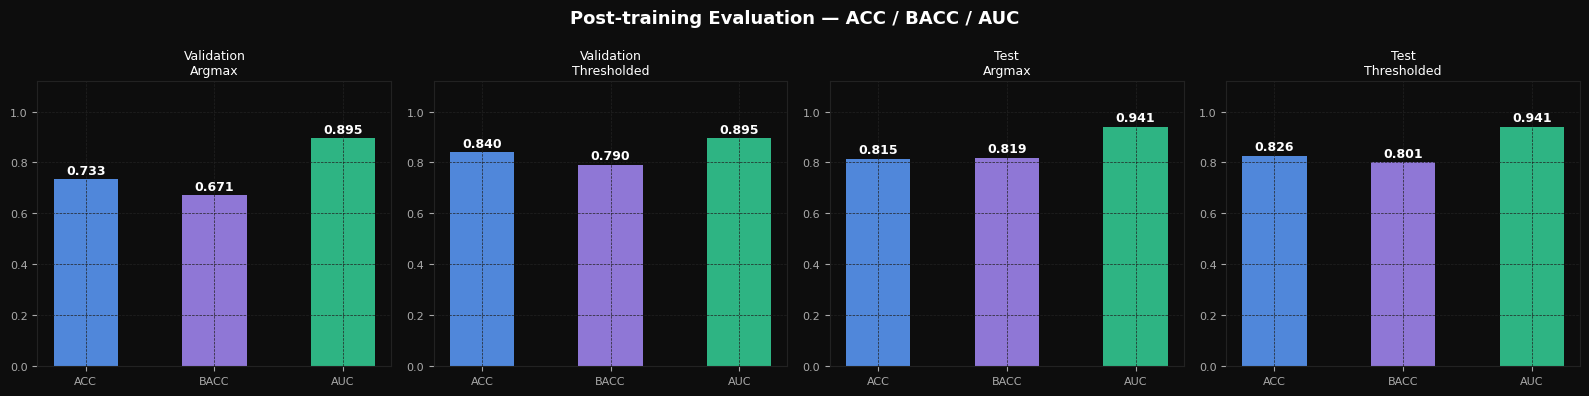

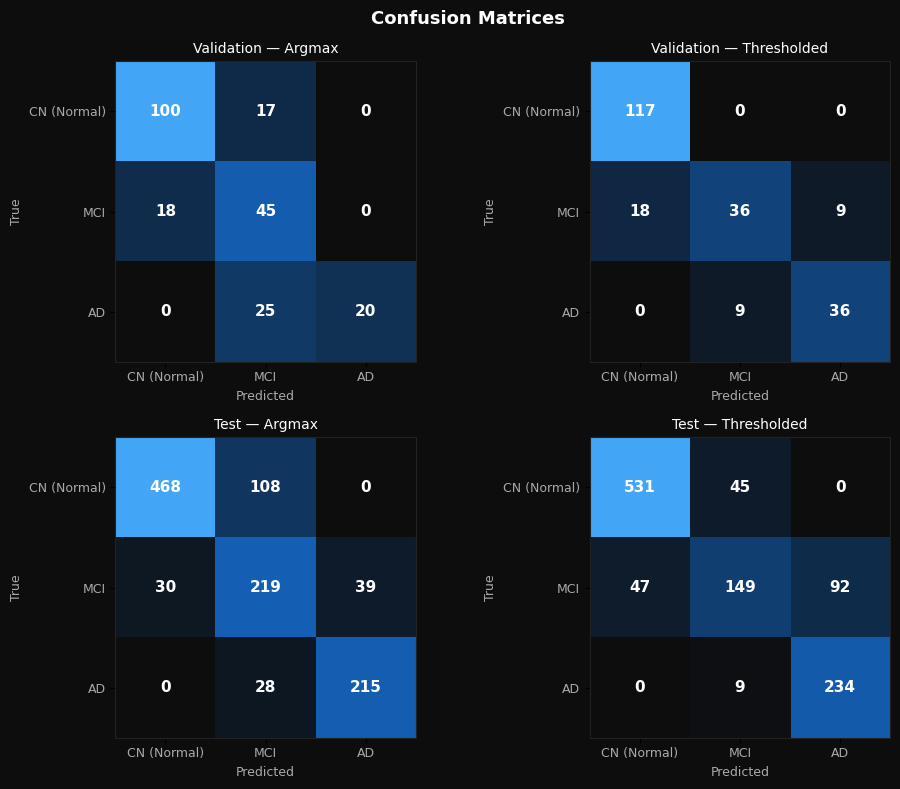

Plots saved to: /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/eval_plots


In [70]:
# Post-training evaluation — metrics table + plots
%matplotlib inline
import os, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import torch, torch.nn.functional as F
from torch.utils.data import DataLoader

EVAL_DIR = os.path.join(OUT_DIR, "eval_plots")
os.makedirs(EVAL_DIR, exist_ok=True)

# Load best model and restore temperature scaler + thresholds
best_model_v4 = ADClassifierV3(freeze_backbone=True).to(DEVICE)
best_model_v4.load_state_dict(
    torch.load(MODEL_SAVE, map_location=DEVICE, weights_only=False))
best_model_v4.eval()

temp_scaler_fin = TemperatureScaler().to(DEVICE)
temp_scaler_fin.log_temp.data = torch.tensor(
    np.log(best_fold['temperature']), dtype=torch.float32, device=DEVICE)
optimal_thresholds = best_fold['thresholds']

# Restore the clinical feature scaler used during training
_snap = load_resume(best_fold['fold'])
_best_scaler = (_snap['fold_scaler'] if _snap and 'fold_scaler' in _snap
                else StandardScaler().fit(
                    np.stack([r['clinical'] for r in best_fold['va_recs']])))

# Normalise clinical features for val and test
va_recs = best_fold['va_recs']
te_recs = best_fold['te_recs']
for r in va_recs + te_recs:
    r['clinical_norm'] = _best_scaler.transform(r['clinical'][None])[0]

# Build datasets and loaders
ds_va_fin = BrainDataset(va_recs, augment=False)
ds_te_fin = BrainDataset(te_recs, augment=False)
dl_va_fin = DataLoader(ds_va_fin, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=NUM_WORKERS, collate_fn=collate_multislice)
dl_te_fin = DataLoader(ds_te_fin, batch_size=1, shuffle=False,
                       num_workers=0, collate_fn=collate_multislice)


# Collect softmax probs, labels, and clinical-only probs for a full split
def collect_preds(model, loader, temp_scaler):
    probs_out, lbls_out, clin_probs_out = [], [], []
    with torch.no_grad():
        for mri_v, pet_v, syn_v, clin, label, cog_v, cog_m, rpf, hsf in loader:
            mri_v = move_views(mri_v, DEVICE)
            pet_v = move_views(pet_v, DEVICE)
            syn_v = move_views(syn_v, DEVICE)
            clin  = clin.to(DEVICE)
            logits, _, clin_aux = model(
                mri_v, pet_v, syn_v, clin, real_pet_mask=rpf.to(DEVICE))
            logits = temp_scaler(logits)
            probs_out.extend(F.softmax(logits, -1).cpu().numpy())
            clin_probs_out.extend(F.softmax(clin_aux, -1).cpu().numpy())
            lbls_out.extend(label.numpy())
    return np.array(probs_out), np.array(lbls_out), np.array(clin_probs_out)


# Run inference on both splits
print("Running inference...")
va_probs, va_lbls, va_clin_probs = collect_preds(best_model_v4, dl_va_fin, temp_scaler_fin)
te_probs, te_lbls, te_clin_probs = collect_preds(best_model_v4, dl_te_fin, temp_scaler_fin)

# Pre-compute metrics for all four conditions (val/test × argmax/thresholded)
metrics = {}
conditions = [
    ("Validation", "Argmax",      va_probs, va_probs.argmax(1),                               va_lbls),
    ("Validation", "Thresholded", va_probs, threshold_predict(va_probs, optimal_thresholds),   va_lbls),
    ("Test",       "Argmax",      te_probs, te_probs.argmax(1),                               te_lbls),
    ("Test",       "Thresholded", te_probs, threshold_predict(te_probs, optimal_thresholds),   te_lbls),
]
for split_name, dec_name, probs_, preds_, lbls_ in conditions:
    try:    auc_ = roc_auc_score(lbls_, probs_, multi_class='ovr', average='macro')
    except: auc_ = float('nan')
    metrics[f"{split_name}_{dec_name}"] = {
        'acc':  accuracy_score(lbls_, preds_),
        'bacc': balanced_accuracy_score(lbls_, preds_),
        'auc':  auc_,
        'cm':   confusion_matrix(lbls_, preds_, labels=[0, 1, 2]),
        'preds': preds_, 'lbls': lbls_,
    }


# Print metrics table before plotting
col_w = 14
print(f"\n{'Condition':<26} {'ACC':>{col_w}} {'BACC':>{col_w}} {'AUC':>{col_w}}")
print("-" * (26 + col_w * 3 + 3))
for split_name, dec_name, *_ in conditions:
    key = f"{split_name}_{dec_name}"
    m   = metrics[key]
    label = f"{split_name} ({dec_name})"
    print(f"{label:<26} {m['acc']:>{col_w}.3f} {m['bacc']:>{col_w}.3f} {m['auc']:>{col_w}.3f}")
print()


# Shared dark theme
BG   = '#0d0d0d'
GRID = '#222222'

def dark_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(BG)
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.xaxis.label.set_color('#aaaaaa'); ax.yaxis.label.set_color('#aaaaaa')
    ax.title.set_color('white')
    if title:  ax.set_title(title, fontsize=9, pad=5)
    if xlabel: ax.set_xlabel(xlabel, fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(True, color=GRID, linewidth=0.5, linestyle='--')


# Figure 1 — ACC / BACC / AUC bars for all four conditions
cond_labels = ["Validation\nArgmax", "Validation\nThresholded",
               "Test\nArgmax",       "Test\nThresholded"]
cond_keys   = ["Validation_Argmax", "Validation_Thresholded",
               "Test_Argmax",       "Test_Thresholded"]
bar_colors  = ['#5c9dff', '#a78bfa', '#34d399']
metric_keys   = ['acc', 'bacc', 'auc']
metric_labels = ['ACC', 'BACC', 'AUC']

fig1, axes = plt.subplots(1, 4, figsize=(16, 4), facecolor=BG)
fig1.suptitle('Post-training Evaluation — ACC / BACC / AUC',
              color='white', fontsize=13, fontweight='bold')

for ax, label, key in zip(axes, cond_labels, cond_keys):
    vals = [metrics[key][m] for m in metric_keys]
    bars = ax.bar(metric_labels, vals, color=bar_colors, alpha=0.85, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom',
                color='white', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1.12)
    dark_ax(ax, title=label)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'fig1_metrics.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


# Figure 2 — Confusion matrices (val/test × argmax/thresholded)
cmap = mcolors.LinearSegmentedColormap.from_list('dm', ['#0d0d0d', '#1565C0', '#42A5F5'])

fig2, axes = plt.subplots(2, 2, figsize=(10, 8), facecolor=BG)
fig2.suptitle('Confusion Matrices', color='white', fontsize=13, fontweight='bold')

for row, split_name in enumerate(["Validation", "Test"]):
    for col, dec_name in enumerate(["Argmax", "Thresholded"]):
        ax  = axes[row][col]
        cm_ = metrics[f"{split_name}_{dec_name}"]['cm']
        ax.imshow(cm_, cmap=cmap, vmin=0)
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(CLASS_NAMES, color='#aaaaaa', fontsize=9)
        ax.set_yticklabels(CLASS_NAMES, color='#aaaaaa', fontsize=9)
        ax.set_xlabel('Predicted', color='#aaaaaa', fontsize=9)
        ax.set_ylabel('True',      color='#aaaaaa', fontsize=9)
        ax.set_title(f'{split_name} — {dec_name}', color='white', fontsize=10)
        ax.set_facecolor(BG)
        for sp in ax.spines.values(): sp.set_edgecolor(GRID)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, str(cm_[i, j]), ha='center', va='center',
                        color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, 'fig2_confusion_matrices.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(f"Plots saved to: {EVAL_DIR}")

# Benchmark

The goal is to fairly compare how much each imaging modality contributes to the model's
classification performance — without any confounds from architecture differences or
threshold noise.

**Three conditions, same ADClassifierV3 architecture, same test set:**

| Condition | Trained on | Tested with |
|---|---|---|
| MRI Only | MRI + Clinical (PET always zeroed) | MRI + Clinical |
| MRI + Real PET | All modalities | Real PET, equal 1/3 pooling |
| MRI + Synthetic PET | All modalities (same weights as above) | Synthetic PET, 70/30 pooling |

**Why argmax instead of thresholds?**
Per-class thresholds are calibrated on only ~225 validation samples, so they carry
large random variance that can swamp the actual modality signal. Argmax on raw logits
is the same rule for every condition — no calibration variance, no noise.

**Primary metric: AUC.** It is threshold-free and calibration-free. If AUC(SynPET) > AUC(MRIOnly),
synthetic PET genuinely adds discriminative value.

## Setup: fold reconstruction & clinical scaler

In [71]:
import copy, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (confusion_matrix, roc_auc_score, accuracy_score,
                             balanced_accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

BENCH_DIR        = os.path.join(OUT_DIR, "modality_benchmark_v4")
V3_MRI_ONLY_CKPT = os.path.join(BENCH_DIR, "v3_mri_only_model.pt")
_V3_CKPT_PREV    = os.path.join(OUT_DIR, "modality_benchmark_v3", "v3_mri_only_model.pt")
os.makedirs(BENCH_DIR, exist_ok=True)

# Reuse MRI-only checkpoint from v3 run if available
if not os.path.exists(V3_MRI_ONLY_CKPT) and os.path.exists(_V3_CKPT_PREV):
    import shutil
    shutil.copy(_V3_CKPT_PREV, V3_MRI_ONLY_CKPT)
    print(f"Copied V3-MRIOnly checkpoint from v3 → {V3_MRI_ONLY_CKPT}")

# Rebuild the exact train/val/test split from the best fold
_best_fold_num = best_fold['fold']
_fold_data     = plan['folds'][_best_fold_num]

def _expand_pts(idx_arr):
    recs = []
    for i in idx_arr: recs.extend(unique_patients[i]['records'])
    return recs

_tr_val_recs = _expand_pts(np.array(_fold_data['tr_val_pat_idx']))
_te_recs     = best_fold['te_recs']

# Reproduce exact patient-level train/val split with same seed as main training
_pat_label_map     = {r['base_naccid']: r['label'] for r in _tr_val_recs}
_tr_val_pids       = list(_pat_label_map.keys())
_tr_val_lbls       = [_pat_label_map[p] for p in _tr_val_pids]
_tr_pids, _va_pids = train_test_split(
    _tr_val_pids, test_size=0.2, stratify=_tr_val_lbls, random_state=SEED)
_tr_recs = [r for r in _tr_val_recs if r['base_naccid'] in set(_tr_pids)]
_va_recs = [r for r in _tr_val_recs if r['base_naccid'] in set(_va_pids)]

print(f"Best fold: {_best_fold_num}")
print(f"Records — train={len(_tr_recs)}  val={len(_va_recs)}  test={len(_te_recs)}")

# Restore the clinical scaler from checkpoint, or refit from training records
_snap_b = load_resume(_best_fold_num)
if _snap_b is not None and 'fold_scaler' in _snap_b:
    _bench_scaler = _snap_b['fold_scaler']
    print("Loaded fold scaler from checkpoint")
else:
    _bench_scaler = StandardScaler().fit(np.stack([r['clinical'] for r in _tr_recs]))
    print("Fitted fresh clinical scaler from training records")

for r in _tr_recs + _va_recs + _te_recs:
    r['clinical_norm'] = _bench_scaler.transform(r['clinical'][None])[0]

# Class-weighted focal loss — same recipe as main training
_tr_lbls_arr = np.array([r['label'] for r in _tr_recs])
_cc          = np.bincount(_tr_lbls_arr, minlength=3).astype(float)
_alpha       = torch.tensor(1.0 / (_cc + 1e-6), dtype=torch.float32)
_alpha       = _alpha / _alpha.sum() * 3
_alpha[1]   *= 1.6; _alpha[0] *= 1.2
_alpha       = _alpha / _alpha.sum() * 3
_bench_criterion = FocalLoss(gamma=1.5, class_weights=_alpha.to(DEVICE), label_smoothing=0.05)

Best fold: 1
Records — train=882  val=225  test=1107
Fitted fresh clinical scaler from training records


## V3-MRIOnly training loop

In [72]:
def _run_epoch_mri_forced(model, loader, train=True, optimizer=None,
                           amp_scaler=None, criterion=None):
    # Both PET inputs zeroed every step; model learns purely from MRI + clinical
    model.train() if train else model.eval()
    tot_loss = 0.0
    preds_all, probs_all, lbls_all = [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for mri_v, pet_v, syn_v, clin, label, cog_v, cog_m, rpf, hsf in loader:
            pet_v = [torch.zeros_like(x) for x in pet_v]
            syn_v = [torch.zeros_like(x) for x in syn_v]
            real_pet_mask = torch.zeros(rpf.shape, dtype=torch.bool)

            # Optional MRI view dropout for regularisation
            if train and random.random() < VIEW_DROPOUT_P:
                mri_v = [torch.zeros_like(x) for x in mri_v]

            mri_v = move_views(mri_v, DEVICE)
            pet_v = move_views(pet_v, DEVICE)
            syn_v = move_views(syn_v, DEVICE)
            clin  = clin.to(DEVICE)
            label = label.to(DEVICE)
            cog_v = cog_v.to(DEVICE)
            cog_m = cog_m.to(DEVICE)
            real_pet_mask = real_pet_mask.to(DEVICE)

            with autocast(enabled=(DEVICE == 'cuda')):
                final_logit, cog_pred, clin_aux = model(
                    mri_v, pet_v, syn_v, clin,
                    real_pet_mask=real_pet_mask, return_aux=True)
                l_cls  = criterion(final_logit, label)
                l_clin = criterion(clin_aux,    label)
                l_reg  = reg_loss_masked(cog_pred, cog_v, cog_m)
                loss   = ALPHA_CLS * l_cls + BETA_CLS * l_clin + GAMMA_REG * l_reg

            if train:
                optimizer.zero_grad(set_to_none=True)
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                amp_scaler.step(optimizer); amp_scaler.update()

            tot_loss += loss.item()
            preds_all.extend(final_logit.detach().argmax(-1).cpu().numpy())
            probs_all.extend(F.softmax(final_logit.detach(), -1).cpu().numpy())
            lbls_all.extend(label.cpu().numpy())

    acc = accuracy_score(lbls_all, preds_all)
    try:   auc = roc_auc_score(lbls_all, np.array(probs_all), multi_class='ovr', average='macro')
    except: auc = 0.0
    return tot_loss / len(loader), acc, auc, np.array(probs_all), np.array(lbls_all)

## Train or load the V3-MRIOnly model

In [73]:
_tr_lbls_list = [r['label'] for r in _tr_recs]
_cc_w         = np.bincount(_tr_lbls_list, minlength=3).astype(float)
_sw           = [{0: 1.0, 1: 2.0, 2: 1.0}[l] / (_cc_w[l] + 1e-6) for l in _tr_lbls_list]
_samp  = WeightedRandomSampler(_sw, len(_sw), replacement=True)
_dl_tr = DataLoader(BrainDataset(_tr_recs, augment=True),
                    batch_size=BATCH_SIZE, sampler=_samp,
                    num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'),
                    collate_fn=collate_multislice)
_dl_va = DataLoader(BrainDataset(_va_recs, augment=False),
                    batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=NUM_WORKERS, collate_fn=collate_multislice)

if os.path.exists(V3_MRI_ONLY_CKPT):
    print(f"Loading cached V3-MRIOnly: {V3_MRI_ONLY_CKPT}")
    v3_mri_model = ADClassifierV3(freeze_backbone=True).to(DEVICE)
    v3_mri_model.load_state_dict(
        torch.load(V3_MRI_ONLY_CKPT, map_location=DEVICE, weights_only=False))
    v3_mri_model.eval()

else:
    print("Training V3-MRIOnly (both PET paths zeroed every step)...")
    v3_mri_model = ADClassifierV3(freeze_backbone=True).to(DEVICE)

    # Phase 1: frozen backbone
    print("Phase 1 — frozen backbone")
    P1_EP = 20; PAT = 8
    _opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, v3_mri_model.parameters()),
        lr=LR, weight_decay=WEIGHT_DECAY)
    _sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(_opt1, T_max=P1_EP, eta_min=LR / 20)
    _sc1  = GradScaler(enabled=(DEVICE == 'cuda'))
    _best_va = float('inf'); _pat = 0; _best_st = None; _best_mci_bacc = 0.0

    for ep in range(1, P1_EP + 1):
        tr_l, _, _, _, _                      = _run_epoch_mri_forced(
            v3_mri_model, _dl_tr, True, _opt1, _sc1, _bench_criterion)
        va_l, va_a, va_auc, va_probs, va_lbls = _run_epoch_mri_forced(
            v3_mri_model, _dl_va, False, criterion=_bench_criterion)
        _sch1.step()

        _cm_v    = confusion_matrix(va_lbls, va_probs.argmax(1), labels=[0, 1, 2])
        _mci_sen = _cm_v[1, 1] / (_cm_v[1].sum() + 1e-8)
        _mci_spe = (_cm_v.sum() - _cm_v[1].sum() - _cm_v[:, 1].sum() + _cm_v[1, 1]) / \
                   (_cm_v.sum() - _cm_v[1].sum() + 1e-8)
        _mci_bacc = 0.5 * (_mci_sen + _mci_spe)

        if va_l < _best_va or _mci_bacc > _best_mci_bacc:
            _best_va = va_l; _best_mci_bacc = _mci_bacc; _pat = 0
            _best_st = copy.deepcopy(v3_mri_model.state_dict())
        else:
            _pat += 1

        if ep % 5 == 0 or ep == 1:
            print(f"  [P1 ep{ep:2d}] tr={tr_l:.4f} va={va_l:.4f} "
                  f"acc={va_a:.3f} auc={va_auc:.3f} MCI_BACC={_mci_bacc:.3f}")
        if _pat >= PAT:
            print(f"  Early stop at P1 ep{ep}"); break

    # Phase 2: fine-tune unfrozen ResNet layers
    print("Phase 2 — unfrozen layers 2-4")
    v3_mri_model.load_state_dict(_best_st)
    v3_mri_model.unfreeze_backbones()

    P2_EP = 50; PAT2 = PAT + 4
    _opt2 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, v3_mri_model.parameters()),
        lr=LR / 15, weight_decay=WEIGHT_DECAY)
    _sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(_opt2, T_max=P2_EP, eta_min=LR / 200)
    _sc2  = GradScaler(enabled=(DEVICE == 'cuda'))
    _best_va2 = float('inf'); _pat2 = 0; _best_mci_bacc2 = 0.0

    for ep in range(1, P2_EP + 1):
        tr_l, _, _, _, _                      = _run_epoch_mri_forced(
            v3_mri_model, _dl_tr, True, _opt2, _sc2, _bench_criterion)
        va_l, va_a, va_auc, va_probs, va_lbls = _run_epoch_mri_forced(
            v3_mri_model, _dl_va, False, criterion=_bench_criterion)
        _sch2.step()

        _cm_v    = confusion_matrix(va_lbls, va_probs.argmax(1), labels=[0, 1, 2])
        _mci_sen = _cm_v[1, 1] / (_cm_v[1].sum() + 1e-8)
        _mci_spe = (_cm_v.sum() - _cm_v[1].sum() - _cm_v[:, 1].sum() + _cm_v[1, 1]) / \
                   (_cm_v.sum() - _cm_v[1].sum() + 1e-8)
        _mci_bacc = 0.5 * (_mci_sen + _mci_spe)

        if va_l < _best_va2 or _mci_bacc > _best_mci_bacc2:
            _best_va2 = va_l; _best_mci_bacc2 = _mci_bacc; _pat2 = 0
            _best_st  = copy.deepcopy(v3_mri_model.state_dict())
        else:
            _pat2 += 1

        if ep % 10 == 0 or ep == 1:
            print(f"  [P2 ep{ep:2d}] tr={tr_l:.4f} va={va_l:.4f} "
                  f"acc={va_a:.3f} auc={va_auc:.3f} MCI_BACC={_mci_bacc:.3f}")
        if _pat2 >= PAT2:
            print(f"  Early stop at P2 ep{ep}"); break

    v3_mri_model.load_state_dict(_best_st)
    v3_mri_model.eval()
    torch.save(_best_st, V3_MRI_ONLY_CKPT)
    print(f"V3-MRIOnly saved → {V3_MRI_ONLY_CKPT}")

# Calibrate temperature on validation set with forced MRI-only inputs
print("Calibrating temperature for V3-MRIOnly...")
_va_logits_list, _va_lbl_list = [], []
with torch.no_grad():
    for mri_v, pet_v, syn_v, clin, label, _, _, rpf, _ in _dl_va:
        pet_v = [torch.zeros_like(x) for x in pet_v]
        syn_v = [torch.zeros_like(x) for x in syn_v]
        rpf   = torch.zeros(label.shape, dtype=torch.bool)
        mri_v = move_views(mri_v, DEVICE)
        pet_v = move_views(pet_v, DEVICE)
        syn_v = move_views(syn_v, DEVICE)
        logits, _, _ = v3_mri_model(
            mri_v, pet_v, syn_v, clin.to(DEVICE),
            real_pet_mask=rpf.to(DEVICE), return_aux=True)
        _va_logits_list.append(logits.cpu()); _va_lbl_list.append(label)

_va_logits_cat = torch.cat(_va_logits_list)
_va_labels_cat = torch.cat(_va_lbl_list)
_v3mri_temp_sc = TemperatureScaler().to(DEVICE)
_v3mri_temp    = _v3mri_temp_sc.fit(_va_logits_cat.to(DEVICE), _va_labels_cat.to(DEVICE))
print(f"  Temperature: {_v3mri_temp:.3f}")



Loading cached V3-MRIOnly: /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/modality_benchmark_v4/v3_mri_only_model.pt
Calibrating temperature for V3-MRIOnly...
  Temperature: 0.738


## Cell 4 — Load V3-RealPET / V3-SynPET (same weights, different test inputs)

In [74]:
bench_v3 = ADClassifierV3(freeze_backbone=True).to(DEVICE)
bench_v3.load_state_dict(torch.load(MODEL_SAVE, map_location=DEVICE, weights_only=False))
bench_v3.eval()

bench_temp = TemperatureScaler().to(DEVICE)
bench_temp.log_temp.data = torch.tensor(
    np.log(best_fold['temperature']), dtype=torch.float32, device=DEVICE)

print(f"Loaded multimodal model from: {MODEL_SAVE}")
print(f"  Temperature : {best_fold['temperature']:.3f}")
print(f"  Test records: {len(_te_recs)}")

Loaded multimodal model from: /workspace/Outputs/ad_classifier_v4/cross_attn_v4_best.pt
  Temperature : 1.238
  Test records: 1107


## Inference functions for all three conditions

In [75]:
@torch.no_grad()
def _infer_condition(model, records, temp_sc, condition):
    """
    Run inference for one ablation condition.
    Hard predictions: argmax on raw logits (same rule for all 3 conditions, no threshold noise).
    Soft probs: temperature-scaled softmax, used only for AUC.
    """
    if condition == "mri_only":
        # Zero both PET paths; mask=False forces 70/30 pooling with null synPET token
        mod_recs = [{**r, 'has_real_pet': False, 'has_synpet': False} for r in records]
    elif condition == "real_pet":
        # Real PET loaded; mask=True → equal 1/3 pooling across MRI, rPET, synPET
        mod_recs = [{**r, 'has_real_pet': True, 'has_synpet': False} for r in records]
    elif condition == "syn_pet":
        # Real PET zeroed, synPET loaded; mask=False → 70/30 MRI/synPET
        mod_recs = [{**r, 'has_real_pet': False} for r in records]
    else:
        raise ValueError(f"Unknown condition: {condition!r}")

    ds = BrainDataset(mod_recs, augment=False)
    dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_multislice)
    all_logits, all_probs, all_lbls = [], [], []

    for mri_v, pet_v, syn_v, clin, label, _, _, rpf, _ in dl:
        mri_v = move_views(mri_v, DEVICE)
        pet_v = move_views(pet_v, DEVICE)
        syn_v = move_views(syn_v, DEVICE)
        logits, _, _ = model(mri_v, pet_v, syn_v, clin.to(DEVICE),
                             real_pet_mask=rpf.to(DEVICE), return_aux=True)
        all_logits.extend(logits.detach().cpu().numpy())
        all_probs.extend(F.softmax(temp_sc(logits), dim=-1).detach().cpu().numpy())
        all_lbls.extend(label.numpy())

    logits_arr = np.array(all_logits)
    probs_arr  = np.array(all_probs)
    lbls_arr   = np.array(all_lbls)
    preds_arr  = logits_arr.argmax(axis=1)   # argmax on raw logits
    return probs_arr, preds_arr, lbls_arr


def _compute_metrics(probs, preds, lbls):
    try:    auc_v = roc_auc_score(lbls, probs, multi_class='ovr', average='macro')
    except: auc_v = float('nan')
    return dict(
        probs=probs, preds=preds, lbls=lbls,
        acc   = accuracy_score(lbls, preds),
        bacc  = balanced_accuracy_score(lbls, preds),
        auc   = auc_v,
        prec  = precision_score(lbls, preds, average='macro', zero_division=0),
        rec   = recall_score(   lbls, preds, average='macro', zero_division=0),
        f1    = f1_score(       lbls, preds, average='macro', zero_division=0),
        pc_f1 = f1_score(       lbls, preds, average=None,    zero_division=0),
        pc_rec= recall_score(   lbls, preds, average=None,    zero_division=0),
        pc_pre= precision_score(lbls, preds, average=None,    zero_division=0),
        cm    = confusion_matrix(lbls, preds, labels=[0, 1, 2]),
    )

## Run all three conditions

In [76]:
bench_results = {}

print("Condition 1: MRI Only")
_p, _pr, _l = _infer_condition(v3_mri_model, _te_recs, _v3mri_temp_sc, "mri_only")
bench_results['MRI Only'] = _compute_metrics(_p, _pr, _l)
r = bench_results['MRI Only']
print(f"  AUC={r['auc']:.3f}  BACC={r['bacc']:.3f}  ACC={r['acc']:.3f}  F1={r['f1']:.3f}")

print("Condition 2: MRI + Real PET")
_p, _pr, _l = _infer_condition(bench_v3, _te_recs, bench_temp, "real_pet")
bench_results['MRI + Real PET'] = _compute_metrics(_p, _pr, _l)
r = bench_results['MRI + Real PET']
print(f"  AUC={r['auc']:.3f}  BACC={r['bacc']:.3f}  ACC={r['acc']:.3f}  F1={r['f1']:.3f}")

print("Condition 3: MRI + Synthetic PET")
_p, _pr, _l = _infer_condition(bench_v3, _te_recs, bench_temp, "syn_pet")
bench_results['MRI + Synthetic PET'] = _compute_metrics(_p, _pr, _l)
r = bench_results['MRI + Synthetic PET']
print(f"  AUC={r['auc']:.3f}  BACC={r['bacc']:.3f}  ACC={r['acc']:.3f}  F1={r['f1']:.3f}")

Condition 1: MRI Only
  AUC=0.933  BACC=0.758  ACC=0.707  F1=0.729
Condition 2: MRI + Real PET
  AUC=0.954  BACC=0.874  ACC=0.890  F1=0.877
Condition 3: MRI + Synthetic PET
  AUC=0.923  BACC=0.769  ACC=0.731  F1=0.736


## Plots

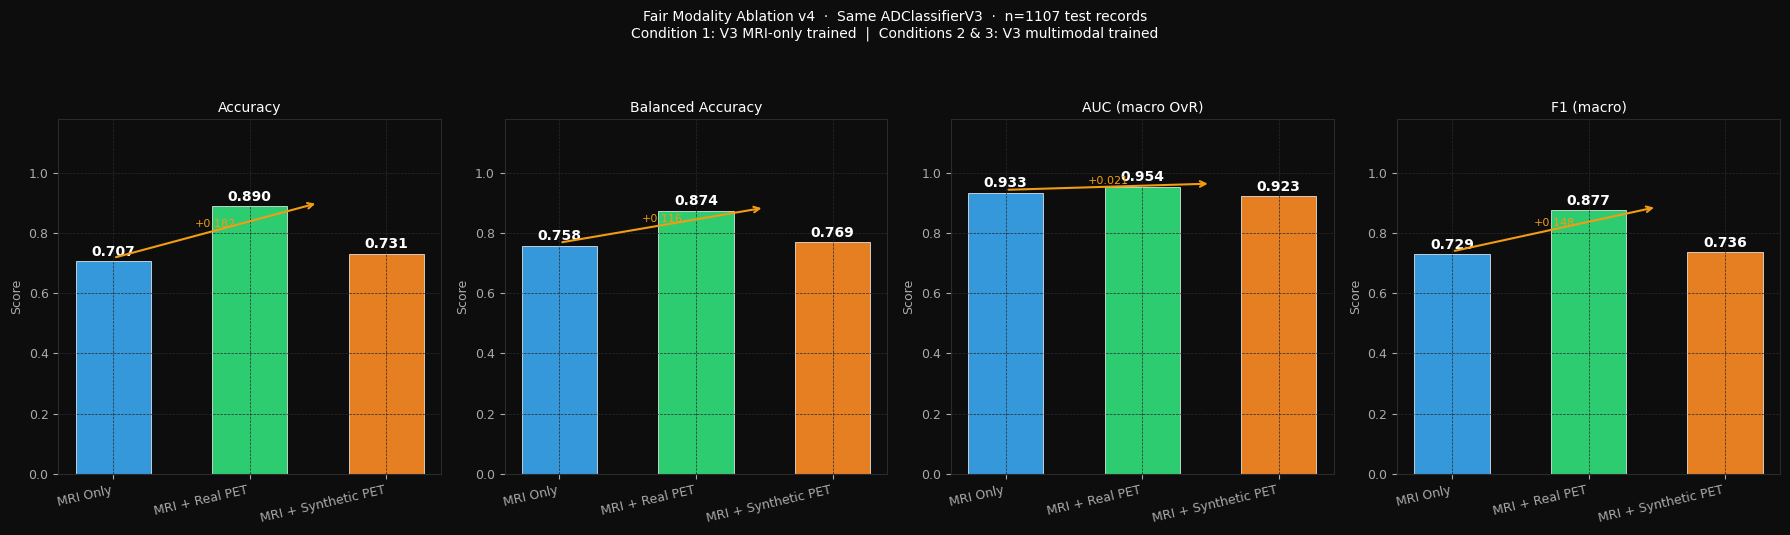

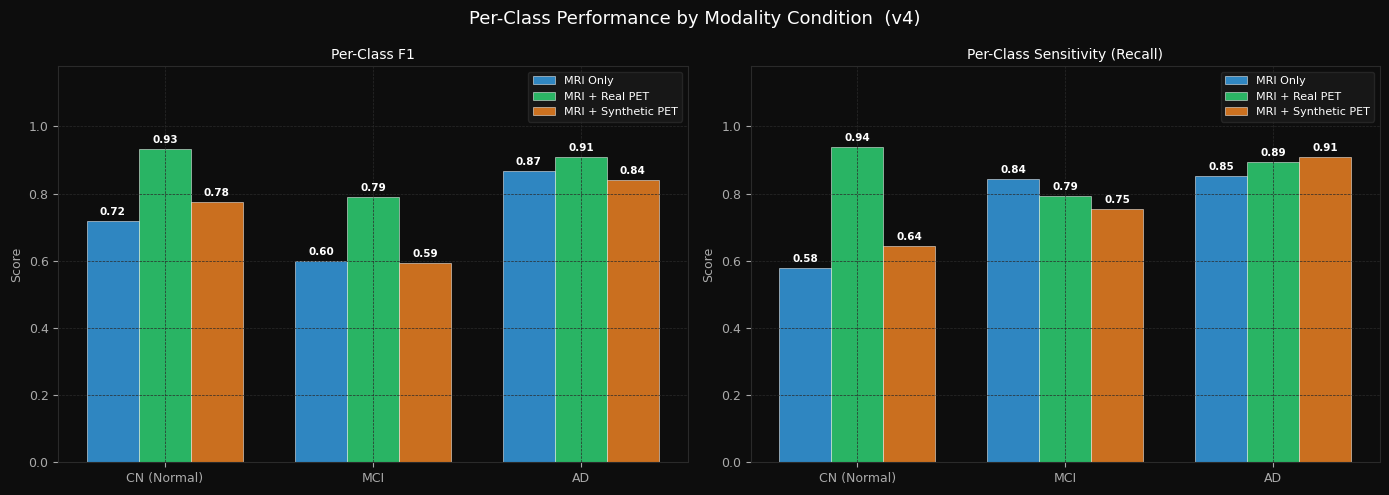

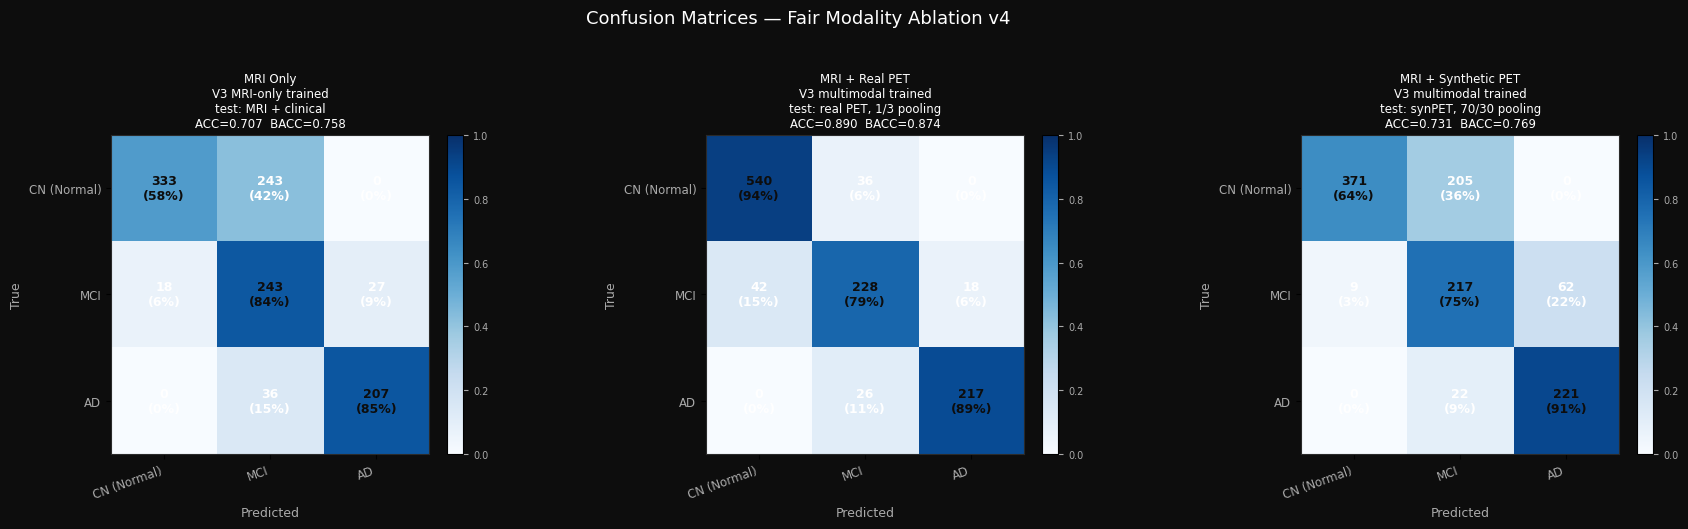

Done. All outputs → /workspace/Outputs/ad_classifier_v4/xai_outputs_v4/modality_benchmark_v4


In [77]:
mode_names = ['MRI Only', 'MRI + Real PET', 'MRI + Synthetic PET']
MODE_COLORS = {
    'MRI Only':            '#3498db',
    'MRI + Real PET':      '#2ecc71',
    'MRI + Synthetic PET': '#e67e22',
}
mc   = [MODE_COLORS[n] for n in mode_names]
BG   = '#0d0d0d'
GRID = '#2a2a2a'

def _style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(BG)
    ax.tick_params(colors='#aaaaaa', labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.xaxis.label.set_color('#aaaaaa'); ax.yaxis.label.set_color('#aaaaaa')
    ax.title.set_color('white')
    if title:  ax.set_title(title,  fontsize=10, pad=5)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, color=GRID, linewidth=0.5, linestyle='--')


# Plot 1 — Overall metrics: ACC, BACC, AUC, F1 for each condition
metric_keys   = ['acc', 'bacc', 'auc', 'f1']
metric_labels = ['Accuracy', 'Balanced Accuracy', 'AUC (macro OvR)', 'F1 (macro)']

fig, axes = plt.subplots(1, 4, figsize=(18, 5), facecolor=BG)
fig.suptitle(
    f'Fair Modality Ablation v4  ·  Same ADClassifierV3  ·  n={len(_te_recs)} test records\n'
    'Condition 1: V3 MRI-only trained  |  Conditions 2 & 3: V3 multimodal trained',
    color='white', fontsize=10, y=1.06)

for ax, mk, ml in zip(axes, metric_keys, metric_labels):
    vals = [bench_results[n][mk] for n in mode_names]
    bars = ax.bar(mode_names, vals, color=mc, edgecolor='white', linewidth=0.5, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008, f'{v:.3f}',
                ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
    # Arrow showing gain from MRI-only to best PET condition
    best_pet = max(bench_results['MRI + Real PET'][mk],
                   bench_results['MRI + Synthetic PET'][mk])
    mri_v = bench_results['MRI Only'][mk]; delta = best_pet - mri_v
    if abs(delta) > 0.001:
        ax.annotate('', xy=(1.5, best_pet + 0.01), xytext=(0, mri_v + 0.01),
                    arrowprops=dict(arrowstyle='->', color='#f39c12', lw=1.5))
        ax.text(0.75, (best_pet + mri_v) / 2 + 0.02, f'{delta:+.3f}',
                ha='center', color='#f39c12', fontsize=8)
    ax.set_ylim(0, min(1.18, max(vals) * 1.3 + 0.06))
    ax.set_xticks(range(len(mode_names)))
    ax.set_xticklabels(mode_names, rotation=13, ha='right', color='#aaaaaa', fontsize=8)
    _style(ax, title=ml, ylabel='Score')

plt.tight_layout()
_p = os.path.join(BENCH_DIR, 'benchmark_v4_01_summary_bars.png')
fig.savefig(_p, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


# Plot 2 — Per-class F1 and sensitivity for each condition
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Per-Class Performance by Modality Condition  (v4)', color='white', fontsize=13)

x = np.arange(3); w = 0.25; offsets = [-w, 0, w]
for ax, mk, title_str in zip(axes, ['pc_f1', 'pc_rec'],
                              ['Per-Class F1', 'Per-Class Sensitivity (Recall)']):
    for i, (name, col) in enumerate(zip(mode_names, mc)):
        vals = bench_results[name][mk]
        bars = ax.bar(x + offsets[i], vals, w, label=name, color=col,
                      edgecolor='white', linewidth=0.4, alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f'{v:.2f}',
                    ha='center', va='bottom', color='white', fontsize=7.5, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color='#aaaaaa', fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=8, facecolor='#1a1a1a', labelcolor='white', edgecolor=GRID, loc='upper right')
    _style(ax, title=title_str, ylabel='Score')

plt.tight_layout()
_p = os.path.join(BENCH_DIR, 'benchmark_v4_02_perclass.png')
fig.savefig(_p, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


# Plot 3 — Normalised confusion matrices for all three conditions
cm_subtitles = {
    'MRI Only':            'V3 MRI-only trained\ntest: MRI + clinical',
    'MRI + Real PET':      'V3 multimodal trained\ntest: real PET, 1/3 pooling',
    'MRI + Synthetic PET': 'V3 multimodal trained\ntest: synPET, 70/30 pooling',
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Confusion Matrices — Fair Modality Ablation v4',
             color='white', fontsize=13, y=1.04)

for ax, name in zip(axes, mode_names):
    cm_  = bench_results[name]['cm']
    cm_n = cm_.astype(float) / cm_.sum(axis=1, keepdims=True).clip(1)
    im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_facecolor(BG)
    ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(CLASS_NAMES, color='#aaaaaa', fontsize=8.5, rotation=20, ha='right')
    ax.set_yticklabels(CLASS_NAMES, color='#aaaaaa', fontsize=8.5)
    ax.set_xlabel('Predicted', color='#aaaaaa', fontsize=9)
    ax.set_ylabel('True',      color='#aaaaaa', fontsize=9)
    ax.set_title(f'{name}\n{cm_subtitles[name]}\n'
                 f'ACC={bench_results[name]["acc"]:.3f}  BACC={bench_results[name]["bacc"]:.3f}',
                 color='white', fontsize=8.5)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm_[i,j]}\n({cm_n[i,j]:.0%})",
                    ha='center', va='center',
                    color='white' if cm_n[i, j] < 0.55 else '#0d0d0d',
                    fontsize=9, fontweight='bold')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(colors='#aaaaaa', labelsize=7)

plt.tight_layout()
_p = os.path.join(BENCH_DIR, 'benchmark_v4_03_confusion_matrices.png')
fig.savefig(_p, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(f"Done. All outputs → {BENCH_DIR}")